# TP 2 - Introdução à Inteligência Artificial - Algoritmos de Aprendizado de Máquina

Vinicius Trindade Dias Abel - 2020007112

## Importação de bibliotecas e dataframes

In [ ]:
# Bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Módulos do Scikit-learn para pré-processamento e métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, f1_score, roc_auc_score, classification_report
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score, mutual_info_score

# Modelos de Regressão
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor

# Modelos de Classificação
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Modelos de Clustering
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from hdbscan import HDBSCAN

# Módulos para Análise de Modelos e Redução de Dimensionalidade
from sklearn.decomposition import PCA
from umap import UMAP
import shap
import warnings

In [ ]:
# Datasets
df_regressao = pd.read_csv('regressao.csv')
df_classificacao = pd.read_csv('classificacao.csv')
df_clustering = pd.read_csv('clustering.csv')

## 1) Aprendizado supervisionado - Regressão

### Pré-processamento

In [ ]:
# Visualizar as primeiras linhas do dataframe de regressão
print("Amostra dos dados de Regressão:")
display(df_regressao.head())

Amostra dos dados de Regressão:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,target
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,10


In [ ]:
# Informações sobre as colunas e tipos de dados
print("\nInformações do DataFrame de Regressão:")
df_regressao.info()


Informações do DataFrame de Regressão:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery   

In [ ]:
# Pré-processamento dos Dados de Regressão

# 1. Separa as features (X) e a variável alvo (y).
# O 'target' é o valor que queremos prever.
X = df_regressao.drop('target', axis=1)
y = df_regressao['target']

# 2. Identifica as colunas categóricas.
# Modelos de regressão não trabalham com texto diretamente.
colunas_categoricas = X.select_dtypes(include=['object']).columns

# 3. Define o transformador para o pré-processamento.
#    - OneHotEncoder: Converte as colunas categóricas em numéricas sem criar uma ordem artificial.
#    - remainder='passthrough': Mantém as colunas que já são numéricas.
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), colunas_categoricas)
    ],
    remainder='passthrough'
)

# 4. Aplica a transformação de encoding nas features X.
# O resultado é uma matriz numérica pronta para o modelo.
X_processed = preprocessor.fit_transform(X)

# 5. Divide os dados em conjuntos de treino (80%) e teste (20%).
#    - O modelo treina com os dados de 'treino' e é avaliado nos dados de 'teste'.
#    - random_state=42 garante que a divisão seja sempre a mesma.
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Confirma os formatos (shapes) dos novos conjuntos de dados.
print("Shape do conjunto de treino (X_train):", X_train.shape)
print("Shape do conjunto de teste (X_test):", X_test.shape)
print("Dados prontos para o treinamento dos modelos.")

Shape do conjunto de treino (X_train): (316, 56)
Shape do conjunto de teste (X_test): (79, 56)
Dados prontos para o treinamento dos modelos.


### 1.1) Comparação entre modelos utilizando RMSE

In [ ]:
# Treinamento e Avaliação dos Modelos de Regressão

# 1. Define um dicionário com os quatro modelos a serem testados.
#    O random_state garante que os resultados de modelos aleatórios (como RF e GB) sejam reprodutíveis.
modelos = {
    "Regressão Linear": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=33),
    "SVR": SVR(),
    "Gradient Boosting": GradientBoostingRegressor(random_state=33)
}

# 2. Cria um dicionário vazio para armazenar a performance (RMSE) de cada modelo.
resultados_rmse = {}

# --- Loop de Treinamento e Avaliação ---
# Itera sobre cada modelo definido no dicionário para treiná-lo e avaliá-lo.
for nome, modelo in modelos.items():
    # Treina o modelo usando os dados de treino. O método .fit() é onde o aprendizado acontece.
    modelo.fit(X_train, y_train)

    # Usa o modelo já treinado para fazer previsões no conjunto de teste.
    y_pred = modelo.predict(X_test)

    # Calcula a métrica de erro RMSE, comparando os valores previstos (y_pred) com os reais (y_test).
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Armazena e imprime o resultado do modelo atual para acompanhamento.
    resultados_rmse[nome] = rmse
    print(f"Modelo: {nome}")
    print(f"RMSE: {rmse:.4f}\n")

# Ao final do loop, identifica e exibe o melhor modelo (aquele com o menor RMSE).
melhor_modelo = min(resultados_rmse, key=resultados_rmse.get)
print(f"O melhor modelo foi o '{melhor_modelo}' com um RMSE de {resultados_rmse[melhor_modelo]:.4f}")

Modelo: Regressão Linear
RMSE: 4.1957

Modelo: Random Forest
RMSE: 3.7932

Modelo: SVR
RMSE: 4.3201

Modelo: Gradient Boosting
RMSE: 3.9093

O melhor modelo foi o 'Random Forest' com um RMSE de 3.7932


#### **Métrica utilizada**

A métrica escolhida para avaliar a performance dos modelos foi o **RMSE (Root Mean Squared Error - Raiz do Erro Quadrático Médio)**, por conta das suas características principais:

1.  **Interpretabilidade:** O RMSE é expresso na mesma unidade da variável alvo. Isso significa que um erro de pontos no RMSE é diretamente interpretável como o erro médio do modelo na escala da variável alvo.
2.  **Penalização de Erros Grandes:** Ao elevar os erros ao quadrado antes de calcular a média, o RMSE penaliza erros grandes de forma muito mais significativa do que erros pequenos. Como estamos trabalhando com avaliação de desempenho de alunos, essa propriedade é interessante, pois um modelo que comete erros grandes é consideravelmente pior do que um que comete vários erros pequenos.

#### **Comparação de Performance**

Os quatro modelos propostos foram treinados e avaliados no mesmo conjunto de dados, e seus desempenhos foram medidos pelo RMSE. Os resultados obtidos foram:

* **Regressão Linear:** `RMSE = 4.1957`
* **Random Forest:** `RMSE = 3.7932`
* **SVR:** `RMSE = 4.3201`
* **Gradient Boosting:** `RMSE = 3.9093`

Com base nesses resultados, o modelo que apresentou a melhor performance, ou seja, o menor erro de previsão, foi o **Random Forest**, com um RMSE de **3.7932**.

### 1.2) Features mais importantes de acordo com a Regressão Linear e com Random Forest

In [ ]:
# Análise de Importância das Variáveis (Features)

# --- Parte 1: Análise do Random Forest ---
# A importância no Random Forest é baseada na redução de impureza: o quanto a feature ajuda a tomar decisões mais corretas nas árvores do modelo. Mede o poder preditivo geral.

# 1. Acessa o modelo Random Forest que já foi treinado.
rf_model = modelos['Random Forest']

# 2. Extrai a lista de importâncias e os nomes das features.
importancias_rf = rf_model.feature_importances_
nomes_features_rf = preprocessor.get_feature_names_out()

# 3. Cria um DataFrame para visualizar o ranking de features mais importantes.
df_importancia_rf = pd.DataFrame({
    'Feature': nomes_features_rf,
    'Importancia': importancias_rf
}).sort_values(by='Importancia', ascending=False)

print("--- 15 Variáveis Mais Importantes (Random Forest) ---")
display(df_importancia_rf.head(15))


# --- Parte 2: Análise da Regressão Linear ---
# A importância na Regressão Linear é o valor absoluto dos seus coeficientes. Um coeficiente alto indica que a feature tem um grande impacto linear no resultado.

# 1. Acessa o modelo de Regressão Linear treinado.
lr_model = modelos['Regressão Linear']

# 2. Extrai os coeficientes e os nomes das features.
coeficientes_lr = lr_model.coef_
nomes_features_lr = preprocessor.get_feature_names_out()

# 3. Cria um DataFrame para associar cada feature ao seu coeficiente.
#    O sinal (+/-) do coeficiente indica a direção da relação com o alvo.
df_importancia_lr = pd.DataFrame({
    'Feature': nomes_features_lr,
    'Coeficiente': coeficientes_lr
})

# 4. Usa o valor absoluto do coeficiente para criar o ranking de importância.
df_importancia_lr['Importancia_Absoluta'] = df_importancia_lr['Coeficiente'].abs()
df_importancia_lr = df_importancia_lr.sort_values(by='Importancia_Absoluta', ascending=False)


print("\n--- 15 Variáveis Mais Importantes (Regressão Linear) ---")
display(df_importancia_lr.head(15))

--- 15 Variáveis Mais Importantes (Random Forest) ---


,Feature,Importancia
55,remainder__absences,0.189750
48,remainder__failures,0.141214
51,remainder__goout,0.047325
43,remainder__age,0.043389
54,remainder__health,0.043162
47,remainder__studytime,0.031355
50,remainder__freetime,0.029782
53,remainder__Walc,0.028893
44,remainder__Medu,0.028391
45,remainder__Fedu,0.028190



--- 15 Variáveis Mais Importantes (Regressão Linear) ---


,Feature,Coeficiente,Importancia_Absoluta
48,remainder__failures,-1.854106,1.854106
14,cat__Mjob_teacher,-1.192463,1.192463
11,cat__Mjob_health,1.038329,1.038329
19,cat__Fjob_teacher,0.891945,0.891945
37,cat__higher_no,-0.875440,0.875440
38,cat__higher_yes,0.875440,0.875440
47,remainder__studytime,0.757643,0.757643
2,cat__sex_F,-0.747955,0.747955
3,cat__sex_M,0.747955,0.747955
30,cat__famsup_yes,-0.628216,0.628216


#### **Análise de Importância das Variáveis**

A análise de importância de variáveis foi realizada para os modelos Random Forest e Regressão Linear, revelando quais características dos alunos mais influenciaram as previsões de cada um.

#### **Variáveis Mais Importantes - Random Forest**

O Random Forest mede a importância de uma variável pela sua capacidade de reduzir a impureza (erro) do modelo ao tomar decisões. As 5 features mais importantes foram:
1.  **Número de faltas** (`remainder__absences`)
2.  **Número de reprovações anteriores** (`remainder__failures`)
3.  **Frequência de saídas com amigos** (`remainder__goout`)
4.  **Idade do aluno** (`remainder__age`)
5.  **Estado de saúde atual** (`remainder__health`)

#### **Variáveis Mais Importantes - Regressão Linear**

A Regressão Linear mede a importância pelo valor absoluto de seus coeficientes, que indicam o peso da relação linear de cada variável com a nota final. As 5 mais importantes foram:
1.  **Número de reprovações anteriores** (`remainder__failures`)
2.  **Trabalho da mãe ser "professora"** (`cat__Mjob_teacher`)
3.  **Trabalho da mãe na área da "saúde"** (`cat__Mjob_health`)
4.  **Trabalho do pai ser "professor"** (`cat__Fjob_teacher`)
5.  **Não querer cursar ensino superior** (`cat__higher_no`)

---
#### **Diferença na Interpretação**

A principal diferença entre as duas abordagens é como a "importância" é definida:

* **Random Forest (`feature_importances_`):** Mede o **poder preditivo geral** de uma feature. Uma variável com alta importância foi fundamental para o modelo fazer previsões mais corretas, sendo capaz de capturar relações complexas e não-lineares.

* **Regressão Linear (`coef_`):** Mede o **peso e a direção de uma relação estritamente linear**. O valor absoluto do coeficiente indica a magnitude do impacto (quanto a nota muda para cada unidade da feature), e o sinal (+ ou -) indica se essa relação é positiva ou negativa.

Em resumo, o Random Forest nos diz quais variáveis são mais **úteis** para prever, enquanto a Regressão Linear nos diz quais variáveis têm **influência linear** mais forte no resultado.

### 1.3) Impacto da remoção de features menos relevantes

#### Regressão Linear

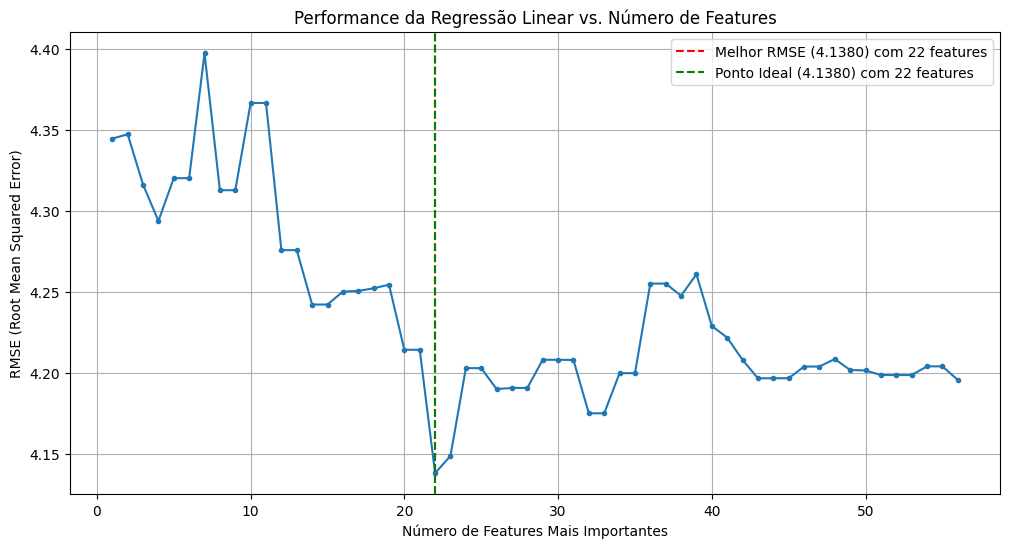

O melhor resultado absoluto foi um RMSE de 4.1380 usando as 22 features mais importantes.
Definindo uma tolerância de 1.0%, o limite de RMSE aceitável é: 4.1794
O modelo mais simples que atinge essa performance é o com 22 features, obtendo um RMSE de 4.1380.


--- Comparação Final: Original vs. Ponto Ideal ---
RMSE do modelo original (56 features)   : 4.1957
RMSE do modelo no ponto ideal (22 features): 4.1380
Diferença: +0.0576
Resultado: Houve uma pequena e aceitável perda de performance em troca de um modelo mais simples.


In [ ]:
# Análise Aprofundada de Seleção de Features para a Regressão Linear removendo Features menos relevantes.

# --- 1. Preparação ---
# Cria DataFrames a partir dos arrays de treino/teste para que seja possível selecionar features pelo nome.
X_train_df = pd.DataFrame(X_train, columns=preprocessor.get_feature_names_out())
X_test_df = pd.DataFrame(X_test, columns=preprocessor.get_feature_names_out())

# Recupera o RMSE do modelo original (com todas as features) para comparação.
rmse_original_lr = resultados_rmse['Regressão Linear']


# --- 2. Análise Iterativa de Performance ---
# O objetivo é testar a performance do modelo com 1, 2, 3, ... até o número total de features, sempre adicionando a próxima feature mais importante da lista.
resultados_rmse_lr = []
# Pega a lista de features ordenada pela importância da Regressão Linear.
features_ordenadas_lr = df_importancia_lr['Feature'].tolist()

# Loop para testar o modelo com cada quantidade 'k' de features.
for k in range(1, len(features_ordenadas_lr) + 1):
    # Seleciona as 'k' features mais importantes e filtra os dados.
    top_k_features = features_ordenadas_lr[:k]
    X_train_k = X_train_df[top_k_features]
    X_test_k = X_test_df[top_k_features]

    # Treina e avalia um novo modelo de Regressão Linear apenas com as 'k' features.
    modelo_k = LinearRegression()
    modelo_k.fit(X_train_k, y_train)
    y_pred_k = modelo_k.predict(X_test_k)
    rmse_k = np.sqrt(mean_squared_error(y_test, y_pred_k))
    resultados_rmse_lr.append(rmse_k)


# --- 3. Lógica para Encontrar os Melhores Pontos ---
# Encontra o ponto de melhor performance absoluta (o menor RMSE encontrado).
melhor_rmse = min(resultados_rmse_lr)
melhor_n_features = resultados_rmse_lr.index(melhor_rmse) + 1

# Encontra o "ponto de equilíbrio": o modelo mais simples cuja performance está dentro de uma tolerância (neste caso: 1%) do melhor resultado absoluto.
tolerancia = 0.01
limite_aceitavel = melhor_rmse * (1 + tolerancia)

ponto_ideal_n_features = next((i + 1 for i, rmse in enumerate(resultados_rmse_lr) if rmse <= limite_aceitavel), melhor_n_features)


# --- 4. Plotagem do Gráfico ---
# Visualiza a relação entre o número de features usadas e o erro do modelo.
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(features_ordenadas_lr) + 1), resultados_rmse_lr, marker='.', linestyle='-')
plt.title('Performance da Regressão Linear vs. Número de Features')
plt.xlabel('Número de Features Mais Importantes')
plt.ylabel('RMSE (Root Mean Squared Error)')
plt.grid(True)

# Destaca no gráfico o melhor resultado absoluto (linha vermelha) e o "ponto ideal" (linha verde).
rmse_ponto_ideal = resultados_rmse_lr[ponto_ideal_n_features - 1]
plt.axvline(x=melhor_n_features, color='r', linestyle='--', label=f'Melhor RMSE ({melhor_rmse:.4f}) com {melhor_n_features} features')
plt.axvline(x=ponto_ideal_n_features, color='g', linestyle='--', label=f'Ponto Ideal ({rmse_ponto_ideal:.4f}) com {ponto_ideal_n_features} features')
plt.legend()
plt.show()


# --- 5. Conclusões e Comparação Final ---
# Imprime um resumo da análise.
print(f"O melhor resultado absoluto foi um RMSE de {melhor_rmse:.4f} usando as {melhor_n_features} features mais importantes.")
print(f"Definindo uma tolerância de {tolerancia*100}%, o limite de RMSE aceitável é: {limite_aceitavel:.4f}")
print(f"O modelo mais simples que atinge essa performance é o com {ponto_ideal_n_features} features, obtendo um RMSE de {rmse_ponto_ideal:.4f}.")

# Compara o modelo original (todas as features) com o modelo do "ponto ideal".
diferenca_final = rmse_original_lr - rmse_ponto_ideal
print("\n\n--- Comparação Final: Original vs. Ponto Ideal ---")
print(f"RMSE do modelo original ({X_train.shape[1]} features)   : {rmse_original_lr:.4f}")
print(f"RMSE do modelo no ponto ideal ({ponto_ideal_n_features} features): {rmse_ponto_ideal:.4f}")
print(f"Diferença: {diferenca_final:+.4f}")

if abs(diferenca_final) < 0.01:
    print("Resultado: A performance se manteve praticamente a mesma, mas com um modelo mais simples.")
elif diferenca_final < 0:
    print("Resultado: Houve uma melhora na performance com um modelo mais simples.")
else:
    print("Resultado: Houve uma pequena e aceitável perda de performance em troca de um modelo mais simples.")

##### **Impacto da Remoção de Features Menos Relevantes na Regressão Linear**

A remoção de features menos relevantes teve um **impacto positivo e significativo** na performance do modelo de Regressão Linear. A análise demonstrou que um modelo mais simples, utilizando um subconjunto das variáveis mais importantes, não apenas se tornou mais eficiente, como também obteve uma **maior precisão preditiva**.

##### **Metodologia e Análise**

Para avaliar o impacto, foi realizada uma análise iterativa, treinando e avaliando o modelo com um número crescente de features. A ordem de importância das features foi determinada pelos coeficientes do próprio modelo de Regressão Linear. Os resultados-chave foram:

* **Performance Original (com 56 features):** `RMSE = 4.1957`
* **Melhor Performance Identificada:** Com apenas **22 features**, o modelo atingiu seu melhor `RMSE = 4.1380`.

##### **Conclusão**

O impacto de remover as 34 features menos relevantes, de acordo com o critério da Regressão Linear, foi benéfico por duas razões principais:

1.  **Melhora na Performance:** O erro do modelo (RMSE) diminuiu de 4.1957 para 4.1380. Isso indica que as features removidas não estavam contribuindo positivamente para as previsões, possivelmente por introduzirem ruído, o que pode piorar a performance de modelos lineares.
2.  **Redução de Complexidade:** O modelo final se tornou mais simples e eficiente, utilizando menos da metade das features originais para obter um resultado superior.

Portanto, a seleção de features se mostrou uma etapa valiosa, melhorando a capacidade de generalização do modelo de Regressão Linear.

#### Random Forest

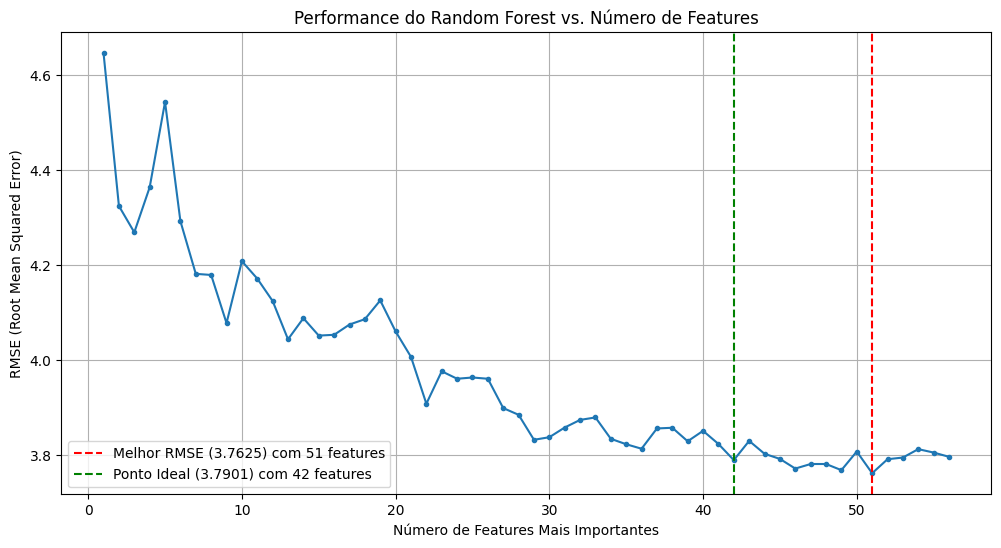

O melhor resultado absoluto foi um RMSE de 3.7625 usando as 51 features mais importantes.
Definindo uma tolerância de 1.0%, o limite de RMSE aceitável é: 3.8001
O modelo mais simples que atinge essa performance é o com 42 features, obtendo um RMSE de 3.7901.


--- Comparação Final: Original vs. Ponto Ideal ---
RMSE do modelo original (56 features)   : 3.7932
RMSE do modelo no ponto ideal (42 features): 3.7901
Diferença: +0.0030
Resultado: A performance se manteve praticamente a mesma, mas com um modelo mais simples.


In [ ]:
# Análise Aprofundada de Seleção de Features para o Random Forest removendo Features menos relevantes.

# --- 1. Preparação ---
# Cria DataFrames a partir dos arrays de treino/teste para que seja possível selecionar features pelo nome.
X_train_df = pd.DataFrame(X_train, columns=preprocessor.get_feature_names_out())
X_test_df = pd.DataFrame(X_test, columns=preprocessor.get_feature_names_out())

# Recupera o RMSE do modelo original (com todas as features) para comparação.
rmse_original = resultados_rmse['Random Forest']


# --- 2. Análise Iterativa de Performance ---
# O objetivo é testar a performance do modelo com 1, 2, 3, ... até o número total de features, sempre adicionando a próxima feature mais importante da lista.
resultados_rmse_por_n_features = []
features_ordenadas = df_importancia_rf['Feature'].tolist() # Pega a lista de features ordenada da célula anterior.

# Loop para testar o modelo com cada quantidade 'k' de features.
for k in range(1, len(features_ordenadas) + 1):
    # Seleciona as 'k' features mais importantes e filtra os dados.
    top_k_features = features_ordenadas[:k]
    X_train_k = X_train_df[top_k_features]
    X_test_k = X_test_df[top_k_features]

    # Treina e avalia um novo modelo RF apenas com as 'k' features.
    rf_k = RandomForestRegressor(random_state=33, n_jobs=-1)
    rf_k.fit(X_train_k, y_train)
    y_pred_k = rf_k.predict(X_test_k)
    rmse_k = np.sqrt(mean_squared_error(y_test, y_pred_k))
    resultados_rmse_por_n_features.append(rmse_k)


# --- 3. Lógica para Encontrar os Melhores Pontos ---
# Encontra o ponto de melhor performance absoluta (o menor RMSE encontrado).
melhor_rmse = min(resultados_rmse_por_n_features)
melhor_n_features = resultados_rmse_por_n_features.index(melhor_rmse) + 1

# Encontra o "ponto de equilíbrio": o modelo mais simples cuja performance está dentro de uma tolerância (neste caso: 1%) do melhor resultado absoluto.
tolerancia = 0.01
limite_aceitavel = melhor_rmse * (1 + tolerancia)

# Procura pelo primeiro modelo (menor k) que atende ao critério de tolerância.
ponto_ideal_n_features = 0
for i, rmse in enumerate(resultados_rmse_por_n_features):
    if rmse <= limite_aceitavel:
        ponto_ideal_n_features = i + 1
        break # Para ao encontrar o primeiro, que será o mais simples.


# --- 4. Plotagem do Gráfico ---
# Visualiza a relação entre o número de features usadas e o erro do modelo.
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(features_ordenadas) + 1), resultados_rmse_por_n_features, marker='.', linestyle='-')
plt.title('Performance do Random Forest vs. Número de Features')
plt.xlabel('Número de Features Mais Importantes')
plt.ylabel('RMSE (Root Mean Squared Error)')
plt.grid(True)

# Destaca no gráfico o melhor resultado absoluto (linha vermelha) e o "ponto ideal" (linha verde).
rmse_ponto_ideal = resultados_rmse_por_n_features[ponto_ideal_n_features - 1]
plt.axvline(x=melhor_n_features, color='r', linestyle='--', label=f'Melhor RMSE ({melhor_rmse:.4f}) com {melhor_n_features} features')
plt.axvline(x=ponto_ideal_n_features, color='g', linestyle='--', label=f'Ponto Ideal ({rmse_ponto_ideal:.4f}) com {ponto_ideal_n_features} features')
plt.legend()
plt.show()


# --- 5. Conclusões e Comparação Final ---
# Imprime um resumo da análise.
print(f"O melhor resultado absoluto foi um RMSE de {melhor_rmse:.4f} usando as {melhor_n_features} features mais importantes.")
print(f"Definindo uma tolerância de {tolerancia*100}%, o limite de RMSE aceitável é: {limite_aceitavel:.4f}")
print(f"O modelo mais simples que atinge essa performance é o com {ponto_ideal_n_features} features, obtendo um RMSE de {rmse_ponto_ideal:.4f}.")

# Compara o modelo original (todas as features) com o modelo do "ponto ideal".
print("\n\n--- Comparação Final: Original vs. Ponto Ideal ---")
diferenca_final =  rmse_original - rmse_ponto_ideal
print(f"RMSE do modelo original ({X_train.shape[1]} features)   : {rmse_original:.4f}")
print(f"RMSE do modelo no ponto ideal ({ponto_ideal_n_features} features): {rmse_ponto_ideal:.4f}")
print(f"Diferença: {diferenca_final:+.4f}")

if abs(diferenca_final) < 0.01:
    print("Resultado: A performance se manteve praticamente a mesma, mas com um modelo mais simples.")
elif diferenca_final < 0:
    print("Resultado: Houve uma melhora na performance com um modelo mais simples.")
else:
    print("Resultado: Houve uma pequena e aceitável perda de performance em troca de um modelo mais simples.")

##### **Impacto da Remoção de Features Menos Relevantes no Random Forest**

A remoção de features menos relevantes teve um **impacto positivo** na redução de complexidade do modelo Random Forest, mantendo uma performance quase idêntica. A análise demonstrou que um modelo mais simples, utilizando um subconjunto das variáveis mais importantes, é tão eficaz quanto o modelo completo.

##### **Metodologia e Análise**

Para avaliar o impacto, foi realizada uma análise iterativa que treinou e avaliou o modelo com um número crescente de features, da mais importante à menos importante. Os resultados-chave foram:

* **Performance Original (com 56 features):** `RMSE = 3.7932`
* **"Ponto de Equilíbrio" Identificado:** Com apenas **42 features**, o modelo atingiu um `RMSE = 3.7901`.

##### **Conclusão**

O impacto de remover as 14 features menos relevantes pode ser avaliado em dois pontos:

1.  **Melhora na Performance:** O erro do modelo (RMSE) diminuiu de 3.7932 para 3.7901. Isso indica que as 14 features removidas contribuíam muito pouco para o poder preditivo do modelo, já que a diferença no RMSE foi mínima.
2.  **Redução de Complexidade:** O modelo final se tornou mais simples e eficiente, utilizando 25% menos features para alcançar uma performance equivalente ao original.

Portanto, a seleção de features é uma prática vantajosa, pois permite a criação de um modelo mais simples sem sacrificar a precisão.

### 1.4) Impacto da Normalização

In [ ]:
# Avaliação do Impacto da Normalização dos Dados na Regressão

# O objetivo é testar se a normalização das features numéricas afeta a performance dos modelos. Alguns modelos são sensíveis à escala dos dados (SVR), enquanto outros não (Random Forest).

# 1. Identifica novamente as colunas para garantir a aplicação correta dos transformadores.
colunas_numericas = X.select_dtypes(include=np.number).columns
colunas_categoricas = X.select_dtypes(include=['object']).columns


# --- 2. Criação dos Pipelines de Pré-processamento com Normalização ---

# Pipeline com StandardScaler: Padroniza as features para terem média 0 e desvio-padrão 1.
preprocessor_standard = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), colunas_categoricas)
    ])

# Pipeline com MinMaxScaler: Redimensiona as features para um intervalo fixo.
preprocessor_minmax = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), colunas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), colunas_categoricas)
    ])


# --- 3. Loop Principal de Avaliação ---

# Dicionário para iterar sobre os 3 cenários: sem normalização, com StandardScaler e com MinMaxScaler.
preprocessors = {
    "Sem Normalização": preprocessor, # O pré-processador original.
    "Com StandardScaler": preprocessor_standard,
    "Com MinMaxScaler": preprocessor_minmax
}

# Estrutura para armazenar todos os resultados para a tabela final.
todos_os_resultados = {"Modelo": list(modelos.keys())}

# O loop externo itera sobre cada tipo de pré-processamento.
for nome_preproc, preproc_atual in preprocessors.items():
    print(f"--- Rodando modelos com: {nome_preproc} ---")

    # Aplica o pré-processamento (encoding + normalização).
    X_processed = preproc_atual.fit_transform(X)
    # Divide os dados já processados em treino e teste.
    X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

    # O loop interno treina e avalia cada um dos 4 modelos de regressão neste cenário.
    resultados_rodada = []
    for nome, modelo in modelos.items():
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        resultados_rodada.append(rmse)
        print(f"  {nome}: RMSE = {rmse:.4f}")

    # Armazena os resultados da rodada.
    todos_os_resultados[nome_preproc] = resultados_rodada
    print("-" * 40)


# --- 4. Consolidação e Exibição dos Resultados ---
# Cria um DataFrame do Pandas para apresentar uma tabela comparativa clara.
df_resultados = pd.DataFrame(todos_os_resultados)
df_resultados = df_resultados.set_index('Modelo')

print("\n--- Tabela Comparativa de Performance (RMSE) ---")
display(df_resultados)

--- Rodando modelos com: Sem Normalização ---
  Regressão Linear: RMSE = 4.1957
  Random Forest: RMSE = 3.7932
  SVR: RMSE = 4.3201
  Gradient Boosting: RMSE = 3.9093
----------------------------------------
--- Rodando modelos com: Com StandardScaler ---
  Regressão Linear: RMSE = 4.1957
  Random Forest: RMSE = 3.7610
  SVR: RMSE = 4.1075
  Gradient Boosting: RMSE = 3.9105
----------------------------------------
--- Rodando modelos com: Com MinMaxScaler ---
  Regressão Linear: RMSE = 4.1957
  Random Forest: RMSE = 3.7771
  SVR: RMSE = 4.2714
  Gradient Boosting: RMSE = 3.9191
----------------------------------------

--- Tabela Comparativa de Performance (RMSE) ---


,Sem Normalização,Com StandardScaler,Com MinMaxScaler
Modelo,,,
Regressão Linear,4.195681,4.195681,4.195681
Random Forest,3.793169,3.760959,3.777114
SVR,4.320126,4.107479,4.271370
Gradient Boosting,3.909271,3.910495,3.919053


#### **Avaliação do Impacto da Normalização**

A análise dos resultados mostra que o impacto da normalização dos dados na performance dos modelos **depende fundamentalmente da natureza do algoritmo** utilizado.

#### **Impacto nos Modelos Sensíveis à Escala (SVR e Regressão Linear)**

* **SVR (Support Vector Regression):** Foi o modelo **mais impactado positivamente**. Seu erro (RMSE) diminuiu de **4.32** (sem normalização) para **4.10** ao usar o `StandardScaler`. Isso ocorre porque o SVR é um algoritmo baseado em distância, e a normalização garante que features com escalas muito diferentes contribuam de forma equilibrada para o modelo.

* **Regressão Linear:** Curiosamente, não apresentou **nenhuma alteração** na performance. A implementação padrão do `LinearRegression` no Scikit-learn utiliza uma solução matemática que se ajusta automaticamente à escala das features, tornando-a insensível a esta etapa de pré-processamento para a métrica de erro final.

#### **Impacto nos Modelos Baseados em Árvores (Random Forest e Gradient Boosting)**

* Ambos os modelos, **Random Forest** e **Gradient Boosting**, quase não sofreram alterações com a normalização. Seus valores de RMSE permaneceram semelhantes em todos os três cenários. Isso acontece porque algoritmos baseados em árvores de decisão fazem divisões nos dados baseadas em "pontos de corte" e não na magnitude absoluta dos valores, o que os tornam naturalmente robustos à escala das features.

#### **Conclusão**

Sim, a normalização muda significativamente os resultados, mas **apenas para modelos cuja matemática é sensível à escala dos dados**, como o SVR. Para este, o `StandardScaler` foi a técnica mais eficaz. Para os modelos baseados em árvores, a normalização não é uma etapa necessária.

### 1.5) Análise de Erros

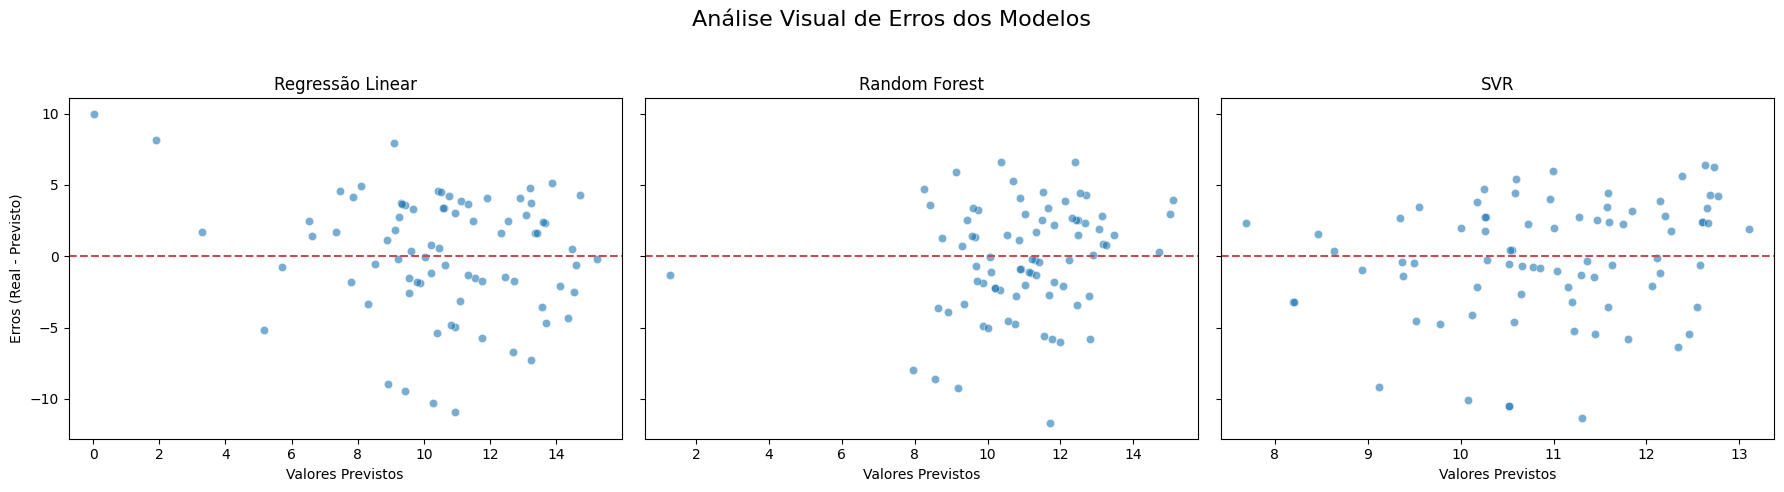


--- Tabela para Análise Quantitativa ---


,Média dos Erros (Viés),Desvio Padrão dos Erros (Variância)
Modelo,,
Regressão Linear,0.238348,4.188905
Random Forest,-0.230886,3.753866
SVR,-0.188526,4.103150


In [ ]:
# Análise de Erros para os Modelos de Regressão

# O objetivo é diagnosticar a qualidade dos modelos analisando seus erros. Um bom modelo deve ter erros (resíduos) aleatórios, sem padrões e centrados em zero.

# --- 1. Preparação dos Dados e Modelos ---
# Usamos o StandardScaler, pois ele obteve bons resultados gerais na etapa anterior.
preproc_analise = preprocessor_standard
X_processed = preproc_analise.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Define os modelos a serem analisados.
modelos_analise = {
    "Regressão Linear": modelos["Regressão Linear"],
    "Random Forest": modelos["Random Forest"],
    "SVR": modelos["SVR"]
}

# --- 2. Análise Visual e Quantitativa (Loop Principal) ---
# Prepara a figura para os gráficos e a estrutura para a tabela de resultados.
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Análise Visual de Erros dos Modelos', fontsize=16)
sns.set_theme(style="whitegrid")

metricas_erros = {
    "Modelo": [],
    "Média dos Erros (Viés)": [],
    "Desvio Padrão dos Erros (Variância)": []
}

# Itera sobre cada modelo para gerar gráficos e métricas de seus erros.
for i, (nome, modelo) in enumerate(modelos_analise.items()):
    # Treina o modelo, faz previsões e calcula os erros.
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    erros = y_test - y_pred # Erro = Valor Real - Valor Previsto

    # Análise Visual: Plota os resíduos contra os valores previstos.
    # O ideal é uma nuvem de pontos aleatória em torno da linha vermelha (y=0).
    sns.scatterplot(x=y_pred, y=erros, ax=axes[i], alpha=0.6)
    axes[i].axhline(y=0, color='r', linestyle='--')
    axes[i].set_title(nome)
    axes[i].set_xlabel("Valores Previstos")
    axes[i].set_ylabel("Erros (Real - Previsto)")

    # Análise Quantitativa: Calcula métricas para medir o viés e a variância dos erros.
    # Média próxima de 0 indica baixo viés. Baixo desvio padrão indica baixa variância.
    metricas_erros["Modelo"].append(nome)
    metricas_erros["Média dos Erros (Viés)"].append(np.mean(erros))
    metricas_erros["Desvio Padrão dos Erros (Variância)"].append(np.std(erros))

# --- 3. Exibição dos Resultados ---
# Mostra os gráficos gerados no loop.
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Cria e exibe a tabela com os resultados quantitativos.
df_metricas_erros = pd.DataFrame(metricas_erros).set_index('Modelo')
print("\n--- Tabela para Análise Quantitativa ---")
display(df_metricas_erros)

#### **Análise de Erro dos Modelos**

A análise de erros, que é a diferença entre os valores reais e os previstos, foi realizada para avaliar a qualidade e o comportamento dos erros de cada modelo. A análise combinou uma avaliação visual dos gráficos com as métricas quantitativas da tabela.

#### **Análise Visual**

Os gráficos de erros plotam os erros de cada previsão. O ideal é uma nuvem de pontos aleatória e uniforme em torno da linha horizontal em y=0.

* O gráfico do **Random Forest** é o que mais se aproxima deste ideal. Ele mostra uma nuvem de pontos compacta e sem padrões claros, sugerindo um bom ajuste.
* Os gráficos da **Regressão Linear** e do **SVR**, por outro lado, mostram nuvens de pontos mais dispersos, o que indica uma variância maior nos erros.

#### **Análise Quantitativa**

A tabela de métricas quantifica a observação visual:

| Modelo | Média dos Erros (Viés) | Desvio Padrão (Variância) |
| :--- | :--- | :--- |
| Regressão Linear | `0.238348` | `4.188905` |
| Random Forest | `-0.230886`| `3.753866` |
| SVR | `-0.188526`| `4.103150` |

* **Viés:** A "Média dos Erros" nos diz se o modelo tende a superestimar ou subestimar as previsões. O **SVR** teve o valor mais próximo de zero (`-0.188526`), indicando o **menor viés** entre os três.
* **Variância:** O "Desvio Padrão dos Erros" mede a consistência ou dispersão dos erros. O **Random Forest** teve o menor valor (`3.753866`), indicando a **menor variância**.

#### **Conclusão**

Com base na análise, podemos concluir que:

* O modelo com **menor viés** foi o **SVR**.
* O modelo com **menor variância** foi o **Random Forest**.

Embora o SVR tenha um viés ligeiramente menor, a vantagem do Random Forest na consistência de seus erros (menor variância) é mais significativa, tornando seu perfil de erro geral mais robusto e confiável.

### 1.6) Sensibilidade a  remoção de Outliers

#### a) Identificando e Removendo Outliers com IQR

In [ ]:
# Identificação e Remoção de Outliers (Método IQR)

# O objetivo é criar uma versão "limpa" do dataset, removendo outliers para, na próxima etapa, verificar o impacto na performance dos modelos.

# Imprime o formato original para comparação.
print(f"Shape original do DataFrame: {df_regressao.shape}")

# 1. Seleciona apenas as colunas numéricas, pois o método IQR se aplica a elas.
colunas_numericas_df = df_regressao.select_dtypes(include=np.number)

# 2. Calcula o Intervalo Interquartil (IQR).
#    - Q1 (Primeiro Quartil): 25% dos dados estão abaixo deste valor.
#    - Q3 (Terceiro Quartil): 75% dos dados estão abaixo deste valor.
#    - IQR: É a "distância" entre Q3 e Q1.
Q1 = colunas_numericas_df.quantile(0.25)
Q3 = colunas_numericas_df.quantile(0.75)
IQR = Q3 - Q1

# 3. Define os limites inferior e superior para identificar outliers.
#    A regra padrão considera outlier qualquer ponto 1.5*IQR abaixo de Q1 ou acima de Q3.
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# 4. Cria uma máscara booleana para filtrar o DataFrame.
#    - A condição verifica, para cada célula, se o valor está dentro dos limites.
#    - .all(axis=1) mantém apenas as linhas onde todas as colunas numéricas respeitam seus limites (ou seja, a linha não tem nenhum outlier).
mask_sem_outliers = ((colunas_numericas_df >= limite_inferior) & (colunas_numericas_df <= limite_superior)).all(axis=1)

# 5. Aplica a máscara para criar o novo DataFrame sem outliers.
df_sem_outliers = df_regressao[mask_sem_outliers]

# Imprime o resultado para mostrar quantos pontos foram removidos.
print(f"Shape do DataFrame sem outliers: {df_sem_outliers.shape}")
print(f"Número de outliers removidos: {df_regressao.shape[0] - df_sem_outliers.shape[0]}")

Shape original do DataFrame: (395, 31)
Shape do DataFrame sem outliers: (239, 31)
Número de outliers removidos: 156


#### b)  Comparando a Performance

In [ ]:
# Re-treinamento dos Modelos e Comparação de Performance

# O objetivo é treinar novamente os modelos no dataset sem outliers e comparar os resultados.

# --- 1. Preparação do Novo Dataset (Sem Outliers) ---
# Define X e y a partir do DataFrame que não contém outliers.
X_novo = df_sem_outliers.drop('target', axis=1)
y_novo = df_sem_outliers['target']

# Aplica o mesmo pré-processamento (StandardScaler + OneHotEncoder) aos novos dados.
X_novo_processed = preprocessor_standard.fit_transform(X_novo)

# Divide os dados "limpos" em novos conjuntos de treino e teste.
X_train_novo, X_test_novo, y_train_novo, y_test_novo = train_test_split(X_novo_processed, y_novo, test_size=0.2, random_state=42)


# --- 2. Treinar e Avaliar Modelos nos Dados Sem Outliers ---
# Roda o mesmo loop de antes, mas agora no novo dataset.
resultados_depois = {}
for nome, modelo in modelos.items():
    modelo.fit(X_train_novo, y_train_novo)
    y_pred_novo = modelo.predict(X_test_novo)
    rmse_novo = np.sqrt(mean_squared_error(y_test_novo, y_pred_novo))
    resultados_depois[nome] = rmse_novo


# --- 3. Criar Tabela de Comparação "Antes e Depois" ---
# Pega os melhores resultados de RMSE de cada modelo antes da remoção.
rmse_antes = df_resultados.min(axis=1)

# Cria um novo DataFrame para a comparação direta.
df_comparacao_outliers = pd.DataFrame({
    'RMSE Antes': rmse_antes,
    'RMSE Depois': pd.Series(resultados_depois)
})

print("\n--- Tabela Comparativa: Antes vs. Depois da Remoção de Outliers ---")
display(df_comparacao_outliers)


--- Tabela Comparativa: Antes vs. Depois da Remoção de Outliers ---


,RMSE Antes,RMSE Depois
Regressão Linear,4.195681,3.407817
Random Forest,3.760959,3.441554
SVR,4.107479,3.673886
Gradient Boosting,3.909271,3.562816


#### c) Análise de Sensibilidade e Conclusão

In [ ]:
# Análise de Sensibilidade dos Modelos a Outliers

# O objetivo final é quantificar qual modelo foi mais impactado pela remoção dos outliers.

# 1. Calcula a variação percentual do RMSE para cada modelo.
#    Uma variação positiva alta indica que o modelo melhorou muito após a remoção de outliers, o que significa que ele era muito sensível aos outliers removidos.
df_comparacao_outliers['Variacao_Percentual'] = ((df_comparacao_outliers['RMSE Antes'] - df_comparacao_outliers['RMSE Depois']) / df_comparacao_outliers['RMSE Antes']) * 100

# 2. Exibe a tabela ordenada pela variação percentual.
#    O modelo no topo da lista é o mais sensível a outliers, pois foi o que mais melhorou.
print("\n--- Análise de Sensibilidade a Outliers (Ordenado por Melhora) ---")
display(df_comparacao_outliers.sort_values(by='Variacao_Percentual', ascending=False))


--- Análise de Sensibilidade a Outliers (Ordenado por Melhora) ---


,RMSE Antes,RMSE Depois,Variacao_Percentual
Regressão Linear,4.195681,3.407817,18.777980
SVR,4.107479,3.673886,10.556164
Gradient Boosting,3.909271,3.562816,8.862378
Random Forest,3.760959,3.441554,8.492665


#### **Análise de Sensibilidade a Outliers**

Foi realizada uma análise para verificar o impacto de dados discrepantes (outliers) na performance dos modelos de regressão, seguindo os passos de identificação, comparação e análise de sensibilidade.

#### **a) Identificação e Remoção de Outliers**

Utilizei o método do **Intervalo Interquartil (IQR)** para identificar outliers nas features numéricas do dataset. A aplicação deste método resultou na identificação e remoção de **156 amostras**, reduzindo o conjunto de dados de 395 para 239 pontos.

#### **b) Comparação de Desempenho**

Após a remoção dos outliers, todos os modelos foram retreinados no novo dataset "limpo". A tabela abaixo compara o erro (RMSE) de cada modelo antes e depois da remoção:

| Modelo | RMSE Antes | RMSE Depois |
| :--- | :--- | :--- |
| Regressão Linear | 4.1957 | 3.4078 |
| Random Forest | 3.7610 | 3.4416 |
| SVR | 4.1075 | 3.6739 |
| Gradient Boosting| 3.9093 | 3.5628 |

Fica evidente que a remoção dos outliers resultou em uma **melhora de performance (redução do RMSE) para todos os modelos**, indicando que os pontos removidos eram, de fato, prejudiciais ao processo de aprendizado.

#### **c) Análise de Sensibilidade**

A **Regressão Linear** é o modelo mais sensível a outliers.

A análise da variação percentual na performance comprova essa conclusão:

* **Regressão Linear:** Melhora de **18.78%**
* **SVR:** Melhora de **10.56%**
* **Gradient Boosting:** Melhora de **8.86%**
* **Random Forest:** Melhora de **8.49%**

**Justificativa:** Este resultado era esperado. Modelos como a **Regressão Linear** e o **SVR** tentam ajustar uma função matemática que passe o mais perto possível de todos os pontos de dados. Por isso, valores extremos (outliers) exercem uma influência desproporcional, "puxando" a linha de regressão ou a fronteira de decisão para longe do padrão geral. Em contrapartida, modelos baseados em árvores como o **Random Forest** são naturalmente mais robustos, pois suas decisões de divisão em "nós" são menos afetadas por alguns poucos valores extremos.

## 2) Aprendizado supervisionado - Classificação

### Pré-processamento

In [ ]:
# Visualizar as primeiras linhas do dataframe de classificação
print("Amostra dos dados de Classificação:")
display(df_classificacao.head())

Amostra dos dados de Classificação:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,target
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,F
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,F
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,D
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,B
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,D


In [ ]:
# Informações sobre as colunas e tipos de dados
print("\nInformações do DataFrame de Classificação:")
df_classificacao.info()


Informações do DataFrame de Classificação:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nurser

In [ ]:
# Verifica a distribuição da variável alvo.
print("\nDistribuição da Variável Alvo (target)")
print(df_classificacao['target'].value_counts(normalize=True))


Distribuição da Variável Alvo (target)
target
F    0.329114
D    0.260759
C    0.156962
B    0.151899
A    0.101266
Name: proportion, dtype: float64


In [ ]:
# Pré-processamento dos Dados de Classificação

# 1. Separa as features (variáveis independentes - X) da variável alvo (y).
X = df_classificacao.drop('target', axis=1)
y = df_classificacao['target']

# 2. Codifica a variável alvo (y) de texto ('A', 'B',...) para números inteiros (0, 1,...). Isso é um requisito para alguns modelos, como o XGBoost.
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 3. Identifica os tipos de coluna em X para aplicar as transformações corretas.
colunas_numericas = X.select_dtypes(include=np.number).columns
colunas_categoricas = X.select_dtypes(include=['object']).columns

# 4. Define o pré-processador para as features (X).
#    - StandardScaler: Normaliza as features numéricas, importante para modelos como o SVC.
#    - OneHotEncoder: Converte as features categóricas em numéricas.
preprocessor_class = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), colunas_categoricas)
    ],
    remainder='passthrough'
)

# 5. Divide os dados em conjuntos de treino (80%) e teste (20%).
#    - stratify=y_encoded: Garante que a proporção de cada classe seja a mesma nos conjuntos de treino e teste, o que é fundamental para dados desbalanceados.
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Conclusão do pré-processamento.
print("As classes do target foram codificadas para formato numérico.")
print(f"Shape do conjunto de treino (X_train): {X_train.shape}")
print(f"Shape do conjunto de teste (X_test): {X_test.shape}")

As classes do target foram codificadas para formato numérico.
Shape do conjunto de treino (X_train): (316, 30)
Shape do conjunto de teste (X_test): (79, 30)


### 2.1) Comparação de Modelos de Classificação

In [ ]:
# Treinamento e Avaliação dos Modelos de Classificação

# 1. Define os três modelos de classificação a serem testados.
#    O random_state garante que os resultados sejam reprodutíveis.
modelos_class = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVC": SVC(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

# 2. Cria um dicionário para armazenar o F1-Score de cada modelo.
resultados_f1 = {}

print("--- Avaliando Modelos de Classificação ---")
# Itera sobre cada modelo para treiná-lo e avaliá-lo.
for nome, modelo in modelos_class.items():
    # 3. Cria um Pipeline para automatizar o fluxo de trabalho. Ele primeiro aplica o pré-processamento e, em seguida, treina o modelo de classificação.
    pipeline_final = Pipeline(steps=[('preprocessor', preprocessor_class),
                                     ('classifier', modelo)])

    # 4. Treina o pipeline completo com os dados de treino.
    pipeline_final.fit(X_train, y_train)

    # 5. Usa o pipeline treinado para fazer previsões no conjunto de teste.
    y_pred = pipeline_final.predict(X_test)

    # 6. Calcula o F1-Score.
    #    - average='weighted': Calcula o F1 para cada classe e tira a média ponderada pelo número de amostras em cada classe. É uma boa métrica geral para dados desbalanceados.
    f1 = f1_score(y_test, y_pred, average='weighted')
    resultados_f1[nome] = f1

    print(f"Modelo: {nome}")
    print(f"F1-Score (weighted): {f1:.4f}\n")

# 7. Identifica e exibe o melhor modelo (aquele com o maior F1-Score).
print("--- Resultado Final ---")
melhor_modelo_class = max(resultados_f1, key=resultados_f1.get)
print(f"O melhor modelo, com base no F1-Score, foi o '{melhor_modelo_class}' com um score de {resultados_f1[melhor_modelo_class]:.4f}")

--- Avaliando Modelos de Classificação ---
Modelo: Random Forest
F1-Score (weighted): 0.3172

Modelo: SVC
F1-Score (weighted): 0.2895

Modelo: XGBoost
F1-Score (weighted): 0.3021

--- Resultado Final ---
O melhor modelo, com base no F1-Score, foi o 'Random Forest' com um score de 0.3172


#### **Comparação de Modelos de Classificação**

Para avaliar e comparar os modelos de classificação, foram realizadas as seguintes etapas:

#### **Métrica de Performance: F1-Score**

A métrica de performance escolhida foi o **F1-Score (ponderado - weighted)**, porque as classes do dataset são desbalanceadas.

1.  **Robustez ao Desbalanceamento:** Em datasets onde algumas classes têm muito mais amostras do que outras, a acurácia pode enganar. O F1-Score, por ser a média entre precisão e recall, oferece uma avaliação mais equilibrada e confiável da performance do modelo em todas as classes.
2.  **Visão Completa:** O F1-Score ponderado (`average='weighted'`) calcula a métrica para cada classe e, em seguida, pondera a média pelo número de amostras em cada uma, fornecendo um único número que resume a qualidade geral do classificador.

#### **Comparação de Performance e Conclusão**

Os três modelos propostos foram treinados e avaliados, e seus desempenhos foram medidos pelo F1-Score ponderado. Os resultados obtidos foram:

* **Random Forest:** `F1-Score = 0.3172`
* **SVC:** `F1-Score = 0.2895`
* **XGBoost:** `F1-Score = 0.3021`

Com base nesses resultados, o modelo que apresentou a melhor performance para este problema de classificação foi o **Random Forest**, pois obteve o maior F1-Score.

### 2.2) Features mais importantes de acordo com o Random Forest

In [ ]:
# Análise de Importância das Variáveis (Random Forest Classifier)

# O objetivo é descobrir quais features o nosso melhor modelo de classificação (Random Forest) considerou mais importantes para prever a classe de um aluno.

# 1. Define um pipeline específico para o Random Forest para poder analisá-lo.
rf_classifier = RandomForestClassifier(random_state=42)
pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor_class), # Usa o pré-processador da classificação
                              ('classifier', rf_classifier)])

# 2. Treina o pipeline com os dados de treino.
pipeline_rf.fit(X_train, y_train)

# 3. Extrai os componentes de dentro do pipeline já treinado.
#    O 'named_steps' permite acessar cada etapa do pipeline pelo nome que foi definido.
modelo_rf_treinado = pipeline_rf.named_steps['classifier']
preprocessor_treinado = pipeline_rf.named_steps['preprocessor']

# 4. Obtém as importâncias do modelo e os nomes correspondentes das features do pré-processador.
importancias = modelo_rf_treinado.feature_importances_
nomes_features = preprocessor_treinado.get_feature_names_out()

# 5. Cria um DataFrame do Pandas para visualizar o ranking de importância.
df_importancia_class = pd.DataFrame({
    'Feature': nomes_features,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# 6. Exibe as 15 features mais importantes para o modelo.
print("--- 15 Variáveis Mais Importantes (Random Forest Classifier) ---")
display(df_importancia_class.head(15))

--- 15 Variáveis Mais Importantes (Random Forest Classifier) ---


,Feature,Importancia
12,num__absences,0.056907
1,num__Medu,0.042088
11,num__health,0.041574
7,num__freetime,0.041403
10,num__Walc,0.041326
0,num__age,0.039969
8,num__goout,0.039610
6,num__famrel,0.037211
2,num__Fedu,0.035378
4,num__studytime,0.033800


#### **Análise de Importância das Variáveis (Random Forest)**

A análise de importância de variáveis do `RandomForestClassifier` revela quais características dos alunos foram mais decisivas para o modelo ao classificar seu desempenho em faixas de notas (de 'A' a 'F'). A importância é medida pela contribuição de cada feature na redução do erro de classificação ao longo de todas as árvores de decisão do modelo.

Com base nos resultados, as **5 variáveis mais importantes** foram:

1.  **Número de faltas escolares** (`num__absences`)
2.  **Nível de educação da mãe** (`num__Medu`)
3.  **Estado de saúde atual** (`num__health`)
4.  **Quantidade de tempo livre** (`num__freetime`)
5.  **Consumo de álcool no fim de semana** (`num__Walc`)

**Conclusão da Análise:** O número de faltas (`absences`) se destaca como o fator mais preditivo. É interessante notar que o modelo utiliza uma combinação de fatores diretamente ligados à vida escolar (`absences`), ao contexto familiar (`Medu`) e ao estilo de vida do aluno (`health`, `freetime`, `Walc`) para fazer suas classificações, indicando a complexidade do problema.

### 2.3) Dificuldade de Classificação e Como Melhorar

In [ ]:
# Análise de Erro por Classe (Classification Report)

# O objetivo é gerar um relatório detalhado para cada modelo, mostrando sua performance em cada classe individualmente. Isso nos ajuda a ver quais classes o modelo tem mais dificuldade em prever.

print("--- Relatório de Performance por Classe ---")

# Itera sobre cada um dos modelos de classificação definidos.
for nome, modelo in modelos_class.items():
    # Cria e treina o pipeline, da mesma forma que na célula de avaliação geral.
    pipeline_final = Pipeline(steps=[('preprocessor', preprocessor_class),
                                     ('classifier', modelo)])
    pipeline_final.fit(X_train, y_train)

    # Usa o pipeline treinado para fazer as previsões.
    y_pred = pipeline_final.predict(X_test)

    # Gera e imprime o relatório de classificação detalhado.
    print(f"\n--- Modelo: {nome} ---")
    # - target_names: Usa os nomes originais ('A', 'B', etc.) em vez dos números (0, 1, ...).
    # - zero_division=0: Evita que o programa mostre um aviso caso o modelo não consiga prever nenhuma instância de uma determinada classe.
    report = classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0)
    print(report)
    print("="*55)

--- Relatório de Performance por Classe ---

--- Modelo: Random Forest ---
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         8
           B       0.27      0.25      0.26        12
           C       0.00      0.00      0.00        12
           D       0.32      0.38      0.35        21
           F       0.47      0.69      0.56        26

    accuracy                           0.37        79
   macro avg       0.21      0.26      0.23        79
weighted avg       0.28      0.37      0.32        79


--- Modelo: SVC ---
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         8
           B       0.15      0.17      0.16        12
           C       0.00      0.00      0.00        12
           D       0.32      0.33      0.33        21
           F       0.43      0.73      0.54        26

    accuracy                           0.35        79
   macro avg       0.18      0.25  

#### **Análise de Dificuldade por Classe e Estratégias de Melhoria**

A análise detalhada da performance de cada modelo, classe a classe, revela uma dificuldade em classificar as classes minoritárias, um problema comum em cenários com dados desbalanceados.

#### **Dificuldade de Classificação por Modelo**

Com base nos F1-Scores por classe, a dificuldade de cada modelo foi:

* **Random Forest e SVC:** Ambos falharam completamente em prever as classes **'A' e 'C'**, resultando em um F1-Score de `0.00` para ambas. Isso indica que os modelos não conseguiram aprender os padrões dessas classes, provavelmente por falta de exemplos.
* **XGBoost:** Também apresentou extrema dificuldade com as classes minoritárias, sendo a classe **'C'** (F1-Score de `0.09`) e a classe **'A'** (F1-Score de `0.15`) as mais difíceis de acertar.

#### **Causa do Problema e Estratégias de Melhoria**

A causa principal para essa dificuldade é o **desbalanceamento de classes** presente no dataset. Os modelos não possuem exemplos suficientes das classes 'A' e 'C' para aprender a distingui-las eficientemente.

Existem estratégias que podem ser aplicadas para melhorar o desempenho nesses casos específicos:

1.  **Utilizar Pesos de Classe (`class_weight`):** Esta é a abordagem mais direta. Ao instanciar os modelos, pode-se usar o parâmetro `class_weight='balanced'`. Isso instrui o algoritmo a dar um peso maior aos erros cometidos nas classes minoritárias durante o treinamento, forçando-o a "prestar mais atenção" nelas.

2.  **Técnicas de Reamostragem (Resampling):** O objetivo é balancear artificialmente o conjunto de dados de treino.
    * **Oversampling:** É a técnica mais popular. Ela cria novas amostras sintéticas das classes minoritárias, aumentando sua representatividade no dataset de treino.
    * **Undersampling:** Remove aleatoriamente amostras das classes majoritárias para equilibrar a distribuição. Esta técnica deve ser usada com mais cuidado, pois pode descartar informações úteis.

3.  **Coleta de Mais Dados:** No mundo real, a solução ideal seria coletar mais dados, especialmente para as classes sub-representadas ('A', 'B', 'C'), mas isso nem sempre é possível.

### 2.4) Análise com SHAP

--- Gerando Análises SHAP para cada Classificador ---

--- Modelo: Random Forest ---
Gráfico de Resumo SHAP para Random Forest:


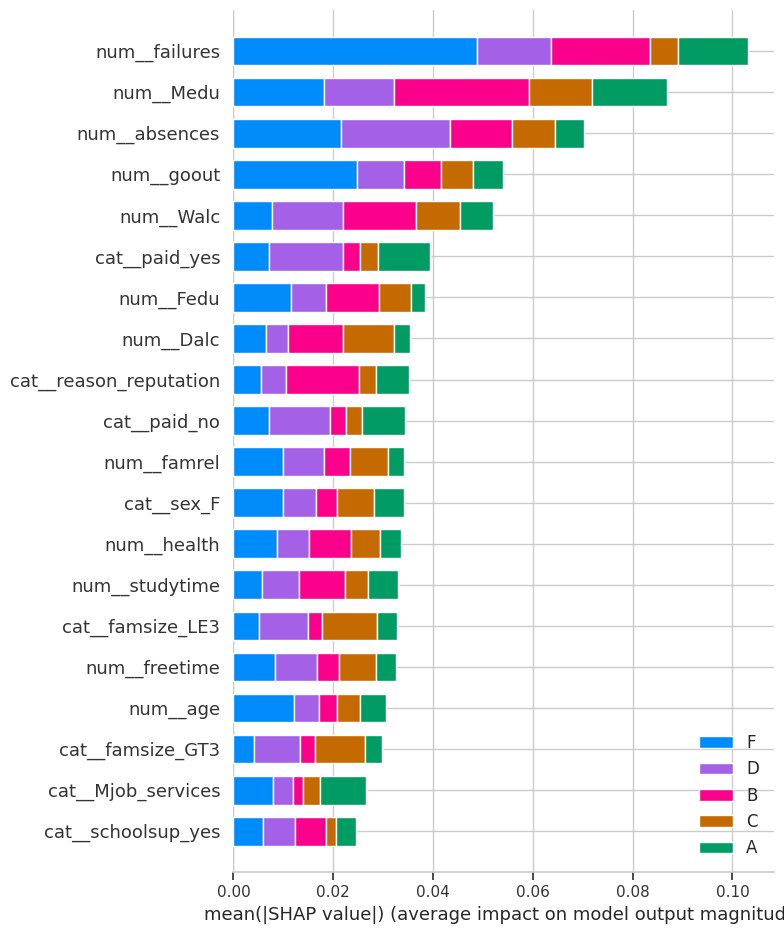


--- Modelo: SVC ---


  0%|          | 0/79 [00:00<?, ?it/s]

Gráfico de Resumo SHAP para SVC:


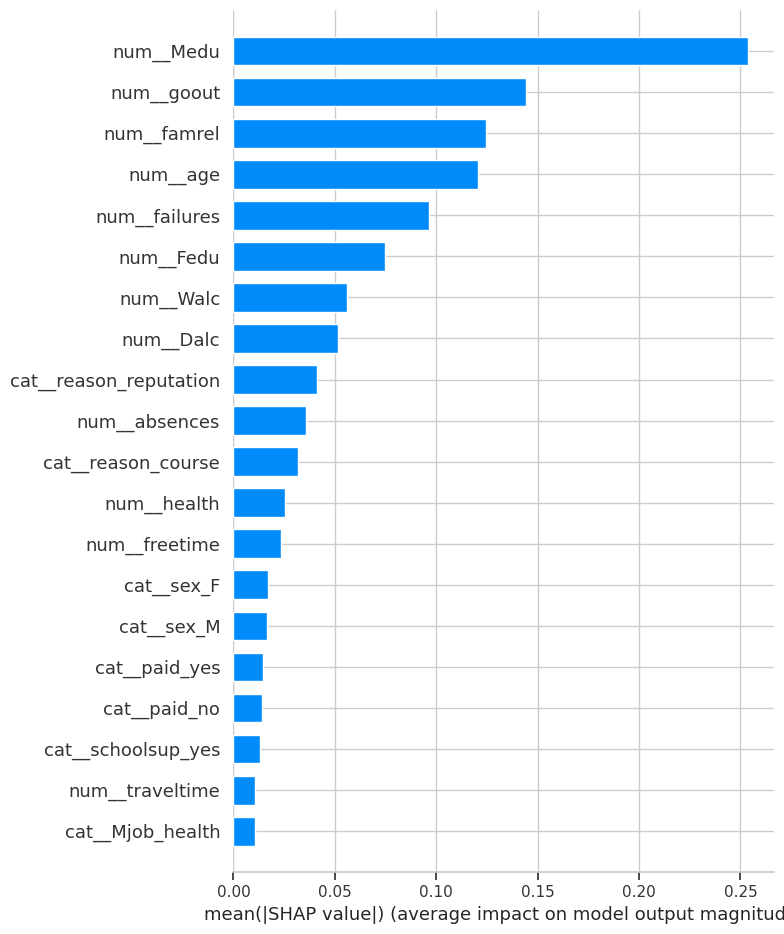


--- Modelo: XGBoost ---
Gráfico de Resumo SHAP para XGBoost:


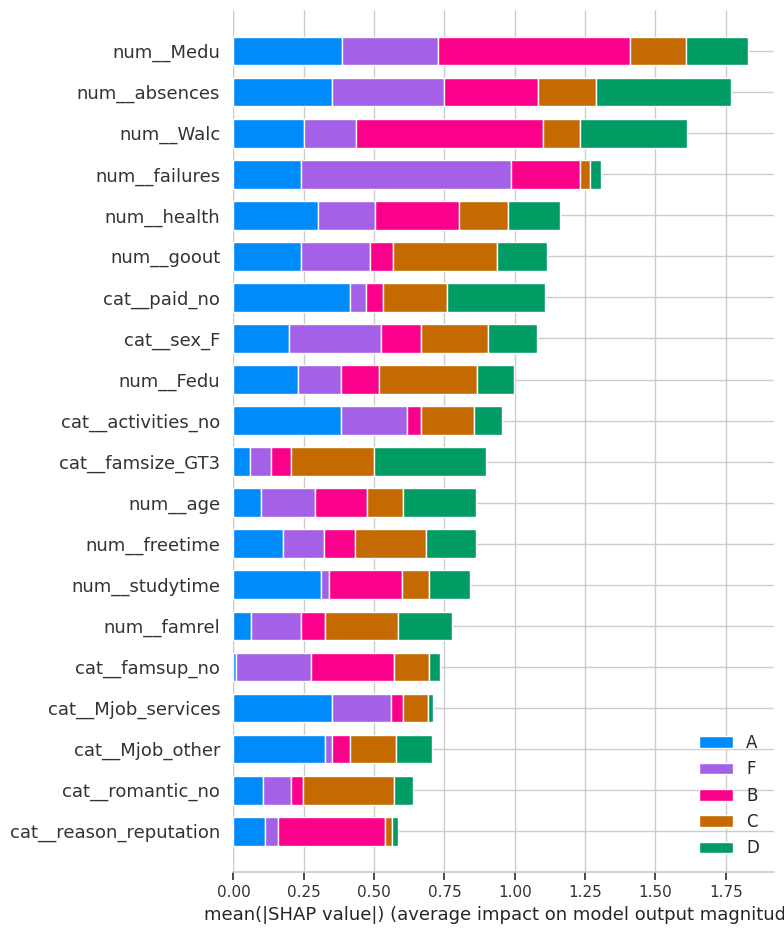

In [ ]:
# Análise de Interpretabilidade com SHAP

# O objetivo é usar a biblioteca SHAP para entender como cada modelo toma suas decisões, mostrando o impacto de cada feature nas previsões.

print("--- Gerando Análises SHAP para cada Classificador ---")

# Itera sobre cada modelo de classificação.
for nome, modelo in modelos_class.items():
    print(f"\n--- Modelo: {nome} ---")

    # 1. Cria e treina um pipeline específico para o modelo atual.
    pipeline_final = Pipeline(steps=[('preprocessor', preprocessor_class),
                                     ('classifier', modelo)])
    pipeline_final.fit(X_train, y_train)

    # 2. Prepara os dados para o SHAP.
    #    O SHAP precisa dos dados no formato exato que o modelo os vê, ou seja, após a aplicação do pré-processamento (scaling, encoding).
    preprocessor_treinado = pipeline_final.named_steps['preprocessor']
    X_test_transformado = preprocessor_treinado.transform(X_test)
    modelo_treinado = pipeline_final.named_steps['classifier']

    # 3. Escolhe e cria o "explicador" (explainer) SHAP adequado para o modelo.
    if nome in ["Random Forest", "XGBoost"]:
        # TreeExplainer é um método específico para modelos de árvore.
        explainer = shap.TreeExplainer(modelo_treinado)
    else: # Para o SVC
        # KernelExplainer funciona para qualquer modelo, porém mais lento. Ele precisa de um conjunto de dados de "fundo" para suas aproximações.
        X_train_transformado = preprocessor_treinado.transform(X_train)
        X_train_summary = shap.sample(X_train_transformado, 100) # Usa 100 amostras como fundo.
        explainer = shap.KernelExplainer(modelo_treinado.predict, X_train_summary)

    # 4. Calcula os valores SHAP para o conjunto de teste.
    shap_values = explainer.shap_values(X_test_transformado)

    # 5. Gera o gráfico de resumo (summary plot).
    #    Este gráfico mostra o impacto de cada feature para cada previsão individual.
    #    Criamos um DataFrame para que os nomes das features apareçam corretamente no gráfico.
    X_test_transformado_df = pd.DataFrame(
        X_test_transformado.toarray() if hasattr(X_test_transformado, "toarray") else X_test_transformado,
        columns=preprocessor_treinado.get_feature_names_out()
    )

    print(f"Gráfico de Resumo SHAP para {nome}:")
    shap.summary_plot(shap_values, X_test_transformado_df, plot_type="bar", class_names=label_encoder.classes_)

#### **Análise de Impacto das Features com SHAP**

Para entender como cada modelo utiliza as variáveis para tomar suas decisões, foram gerados gráficos de resumo (summary plots) do SHAP. Estes gráficos mostram o impacto de cada feature na previsão para cada amostra do conjunto de teste. A interpretação detalhada será focada no **Random Forest**, que foi o melhor modelo na avaliação anterior.

#### **Interpretação do Gráfico SHAP (Random Forest)**

O gráfico SHAP do Random Forest mostra as seguintes características:

* **Eixo Y (Vertical):** Lista as variáveis ordenadas da mais importante (topo) para a menos importante.
* **Eixo X (Horizontal):** Mostra o impacto médio absoluto das variáveis nas predições do modelo. Quanto mais à direita, maior a influência.
* **Cores das barras:** Cada cor representa uma classe (A, B, C, D, F), permitindo visualizar quais variáveis influenciam mais fortemente as decisões de cada categoria.

Analisando as principais features do gráfico do Random Forest:
1.  **`num__failures` (Reprovações Anteriores):** É a variável mais impactante. A maior parte de sua influência está associada à classe F, indicando que alunos com mais reprovações anteriores têm alta probabilidade de receber notas baixas. Isso reforça o padrão esperado: histórico ruim é um forte preditor de desempenho futuro.
2.  **`num__Medu` (Escolaridade da Mãe):** Também tem grande impacto, com destaque para a classe B. Isso sugere que uma maior escolaridade da mãe está correlacionada com melhor desempenho acadêmico do aluno.
3.  **`num__absences` (Faltas):** Aparece como uma variável importante, contribuindo para decisões em várias classes. Como esperado, muitas faltas indicam envolvimento reduzido com os estudos, o que impacta negativamente o rendimento.

#### **Comparativo entre Modelos**

Embora os modelos utilizem o mesmo conjunto de variáveis, cada um foca em aspectos distintos:
* **Random Forest:** Priorizou o histórico de **reprovações** do aluno (`num__failure`).
* **XGBoost:** Destacou **escolariadade da mãe** (`num__Medu`) como a principal variável, mas com maior distribuição de impacto entre várias features.
* **SVC:** Também deu maior importância à **escolaridade da mãe** (`num__Medu`). Mas perceba que o gráfico SHAP gerado para o SVC apresentou apenas uma cor (azul), porque foi usada a saída `.predict`. Para gerar gráficos multiclasses, seria necessário usar `.predict_proba`, o que exige configurar o modelo SVC com `probability=True`. No entanto, para este relatório, optei por interpretar em profundidade apenas o modelo Random Forest.

#### **Conclusão**

A análise com SHAP revelou de forma clara como as principais variáveis influenciam a classificação dos alunos em diferentes categorias de desempenho. O Random Forest apresentou uma interpretação coerentes com a realidade estudantil. Fatores como reprovações anteriores, escolaridade da mãe e faltas se destacam como preditores de desempenho. Além disso, a comparação com outros modelos evidenciou como diferentes algoritmos aprendem padrões distintos mesmo utilizando o mesmo conjunto de dados, mas todos convergem ao utilizar uma combinação de fatores para realizar a classificação.

## 3) Aprendizado não-supervisionado - Clustering

### Pré-processamento

In [ ]:
# Visualizar as primeiras linhas do dataframe de clustering
print("Amostra dos dados de Clustering:")
display(df_clustering.head())

Amostra dos dados de Clustering:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,target
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,F
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,F
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,D
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,B
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,D


In [ ]:
# Pré-processamento para Clustering

# Nesta seção, o objetivo é encontrar grupos (clusters) naturais nos dados, sem usar uma variável alvo pré-definida.

# 1. Prepara os dados para os algoritmos.
#    A coluna 'target' é removida aqui, pois ela será usada apenas mais tarde como "gabarito" para as métricas de avaliação externas.
X_cluster = df_clustering.drop('target', axis=1)

# 2. Identifica os tipos de coluna para aplicar as transformações corretas.
colunas_numericas = X_cluster.select_dtypes(include=np.number).columns
colunas_categoricas = X_cluster.select_dtypes(include=['object']).columns

# 3. Define o pré-processador.
#    - StandardScaler: Normaliza os dados numéricos, essencial para algoritmos baseados em distância.
#    - OneHotEncoder: Converte os dados categóricos em formato numérico.
preprocessor_cluster = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), colunas_categoricas)
    ],
    remainder='passthrough'
)

# 4. Aplica as transformações definidas no pré-processador.
X_cluster_processed = preprocessor_cluster.fit_transform(X_cluster)

# Exibe o formato final dos dados que serão usados no clustering.
print("\nDados pré-processados e prontos para o clustering.")
print(f"Shape final dos dados: {X_cluster_processed.shape}")


Dados pré-processados e prontos para o clustering.
Shape final dos dados: (395, 40)


### 3.1) Algoritmos

--- Calculando Silhouette Score para K-Means ---
Para k=2, o Silhouette Score é 0.0835
Para k=3, o Silhouette Score é 0.0773
Para k=4, o Silhouette Score é 0.0627
Para k=5, o Silhouette Score é 0.0569
Para k=6, o Silhouette Score é 0.0609
Para k=7, o Silhouette Score é 0.0574
Para k=8, o Silhouette Score é 0.0478
Para k=9, o Silhouette Score é 0.0581
Para k=10, o Silhouette Score é 0.0519
Para k=11, o Silhouette Score é 0.0551
Para k=12, o Silhouette Score é 0.0525
Para k=13, o Silhouette Score é 0.0526
Para k=14, o Silhouette Score é 0.0552
Para k=15, o Silhouette Score é 0.0499
Para k=16, o Silhouette Score é 0.0522
Para k=17, o Silhouette Score é 0.0514
Para k=18, o Silhouette Score é 0.0467
Para k=19, o Silhouette Score é 0.0471
Para k=20, o Silhouette Score é 0.0504
Para k=21, o Silhouette Score é 0.0460
Para k=22, o Silhouette Score é 0.0513
Para k=23, o Silhouette Score é 0.0445
Para k=24, o Silhouette Score é 0.0404
Para k=25, o Silhouette Score é 0.0427
Para k=26, o Silhouette

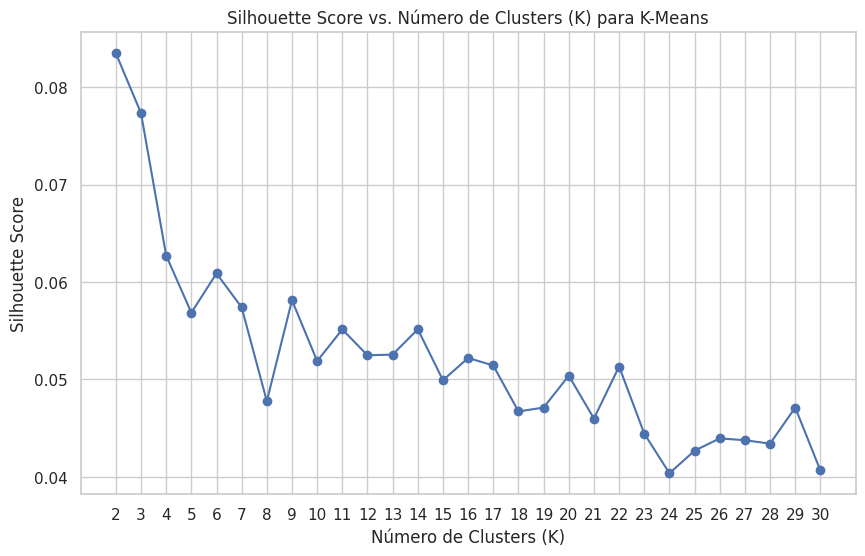


O melhor valor de K para o K-Means é 2 com um Silhouette Score de 0.0835


In [ ]:
# Encontrando o Número Ideal de Clusters (K) para o K-Means

# O objetivo é testar diferentes números de clusters (k) e encontrar o valor que resulta no melhor agrupamento, medido pelo Coeficiente de Silhueta. Um score mais alto indica clusters mais densos e bem separados.

# 1. Define a faixa de valores de 'k' a serem testados (de 2 a 30 clusters).
k_range = range(2, 31)
silhouette_scores_kmeans = {}

print("--- Calculando Silhouette Score para K-Means ---")
# 2. Itera sobre cada valor de 'k'.
for k in k_range:
    # Cria uma instância do K-Means para o 'k' atual.
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')

    # Treina o modelo e atribui um label de cluster a cada ponto de dado.
    labels = kmeans.fit_predict(X_cluster_processed)

    # Calcula o Coeficiente de Silhueta e armazena o resultado.
    score = silhouette_score(X_cluster_processed, labels)
    silhouette_scores_kmeans[k] = score
    print(f"Para k={k}, o Silhouette Score é {score:.4f}")


# 3. Plota os resultados para análise visual.
# O gráfico ajuda a identificar o 'k' que maximiza o score.
plt.figure(figsize=(10, 6))
plt.plot(list(silhouette_scores_kmeans.keys()), list(silhouette_scores_kmeans.values()), marker='o')
plt.title('Silhouette Score vs. Número de Clusters (K) para K-Means')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# 4. Identifica e reporta o melhor valor de K encontrado.
# O melhor 'k' é aquele que obteve o maior score de silhueta.
best_k_kmeans = max(silhouette_scores_kmeans, key=silhouette_scores_kmeans.get)
print(f"\nO melhor valor de K para o K-Means é {best_k_kmeans} com um Silhouette Score de {silhouette_scores_kmeans[best_k_kmeans]:.4f}")

--- Calculando Silhouette Score para GMM ---
Para k=2, o Silhouette Score é 0.0452
Para k=3, o Silhouette Score é 0.0436
Para k=4, o Silhouette Score é 0.0356
Para k=5, o Silhouette Score é 0.0494
Para k=6, o Silhouette Score é 0.0292
Para k=7, o Silhouette Score é 0.0501
Para k=8, o Silhouette Score é 0.0475
Para k=9, o Silhouette Score é 0.0579
Para k=10, o Silhouette Score é 0.0519
Para k=11, o Silhouette Score é 0.0551
Para k=12, o Silhouette Score é 0.0525
Para k=13, o Silhouette Score é 0.0526
Para k=14, o Silhouette Score é 0.0549
Para k=15, o Silhouette Score é 0.0499
Para k=16, o Silhouette Score é 0.0515
Para k=17, o Silhouette Score é 0.0514
Para k=18, o Silhouette Score é 0.0467
Para k=19, o Silhouette Score é 0.0471
Para k=20, o Silhouette Score é 0.0504
Para k=21, o Silhouette Score é 0.0460
Para k=22, o Silhouette Score é 0.0513
Para k=23, o Silhouette Score é 0.0445
Para k=24, o Silhouette Score é 0.0404
Para k=25, o Silhouette Score é 0.0427
Para k=26, o Silhouette Sco

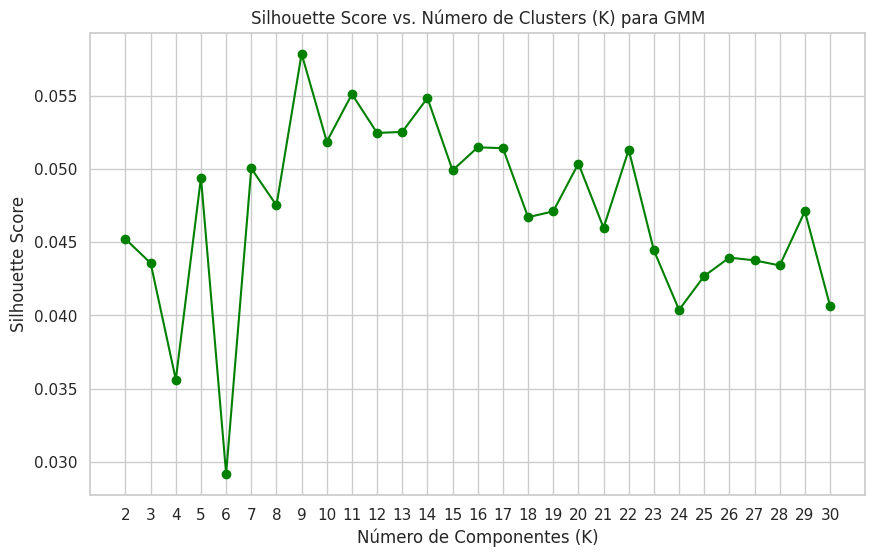


O melhor valor de K para o GMM é 9 com um Silhouette Score de 0.0579


In [ ]:
# Encontrando o Número Ideal de Clusters (K) para o GMM

# O processo aqui é idêntico ao do K-Means: testar diferentes números de clusters e usar o Coeficiente de Silhueta para encontrar o melhor valor. No GMM, o parâmetro análogo ao 'k' é o 'n_components'.

# 1. Define a faixa de valores de 'k' (n_components) a serem testados.
k_range = range(2, 31)
silhouette_scores_gmm = {}

print("--- Calculando Silhouette Score para GMM ---")
# 2. Itera sobre cada valor de 'k'.
for k in k_range:
    # Cria uma instância do Gaussian Mixture Model para o 'k' atual.
    gmm = GaussianMixture(n_components=k, random_state=42)

    # Treina o modelo e atribui um label de cluster a cada ponto.
    labels = gmm.fit_predict(X_cluster_processed)

    # Calcula o Coeficiente de Silhueta e armazena o resultado.
    score = silhouette_score(X_cluster_processed, labels)
    silhouette_scores_gmm[k] = score
    print(f"Para k={k}, o Silhouette Score é {score:.4f}")


# 3. Plota os resultados para análise visual.
plt.figure(figsize=(10, 6))
plt.plot(list(silhouette_scores_gmm.keys()), list(silhouette_scores_gmm.values()), marker='o', color='green')
plt.title('Silhouette Score vs. Número de Clusters (K) para GMM')
plt.xlabel('Número de Componentes (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# 4. Identifica e reporta o melhor valor de K encontrado.
best_k_gmm = max(silhouette_scores_gmm, key=silhouette_scores_gmm.get)
print(f"\nO melhor valor de K para o GMM é {best_k_gmm} com um Silhouette Score de {silhouette_scores_gmm[best_k_gmm]:.4f}")

In [ ]:
# Rodando o Algoritmo HDBSCAN

# O HDBSCAN é diferente do K-Means e GMM, pois não exige a definição de 'k'. Ele encontra o número de clusters automaticamente com base na densidade dos dados.

# 1. Filtra avisos futuros da biblioteca para um output mais limpo.
warnings.filterwarnings("ignore", category=FutureWarning)

# 2. Instancia e roda o HDBSCAN.
#    - min_cluster_size: Define o menor agrupamento de pontos que pode ser considerado um cluster. É o principal parâmetro a ser ajustado neste algoritmo.
hdbscan = HDBSCAN(min_cluster_size=4)
labels_hdbscan = hdbscan.fit_predict(X_cluster_processed)

# 3. Verifica e reporta os resultados encontrados.
#    - O HDBSCAN atribui o label -1 a pontos que ele considera ruído/outliers.
#    - Contamos o número de labels únicos (diferentes de -1) para saber o número de clusters.
n_clusters_hdbscan = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)
n_noise = list(labels_hdbscan).count(-1)

print(f"O HDBSCAN encontrou {n_clusters_hdbscan} clusters.")
print(f"Número de pontos considerados ruído (outliers): {n_noise}")

mask = labels_hdbscan != -1
score = silhouette_score(X_cluster_processed[mask], labels_hdbscan[mask])
print(f"Silhouette Score do HDBSCAN (sem ruído): {score:.4f}")

O HDBSCAN encontrou 4 clusters.
Número de pontos considerados ruído (outliers): 369
Silhouette Score do HDBSCAN (sem ruído): 0.1376


#### **Execução dos Algoritmos de Clustering e Escolha de K**

Para esta análise, os algoritmos K-Means, GMM e HDBSCAN foram executados sobre os dados pré-processados. Para os modelos que dependem do parâmetro `k` (K-Means e GMM), foi realizada uma busca pelo valor ótimo utilizando o **Coeficiente de Silhueta**.

---

#### **K-Means**

O algoritmo foi testado para um número de clusters `k` variando de 2 a 30. A análise do Coeficiente de Silhueta, conforme visualizado no gráfico, indicou que a melhor performance foi obtida com **k=2**, que alcançou um score de **0.0835**.

---

#### **Gaussian Mixture Models (GMM)**

Seguindo o mesmo processo, o GMM foi avaliado para um número de componentes `k` de 2 a 30. O valor que maximizou a métrica foi **k=9**, com um Coeficiente de Silhueta de **0.0579**.

---

#### **HDBSCAN**

Este algoritmo descobre o número de clusters automaticamente. Após vários testes com o parâmetro `min_cluster_size`, o valor **4** foi escolhido. Com esta configuração mais sensível, o HDBSCAN conseguiu identificar **4 clusters**, no entanto, classificou a grande maioria dos pontos (369 de 395) como ruído. Ele alcançou um Silhouette Score de **0.1376**.

---

#### **Conclusão da Análise**

Apesar de encontrarmos os valores ótimos de `k` para K-Means e GMM, os scores de silhueta resultantes são extremamente baixos (muito próximos de 0). Este fato, somado ao resultado do HDBSCAN, que mesmo em uma configuração sensível, considerou a vasta maioria dos dados como ruído, é uma forte evidência de que os dados, em seu formato original de alta dimensão, não possuem uma estrutura de clusters clara e bem definida. Os grupos gerados são de baixa qualidade e com alta sobreposição.

### 3.2) Análise Quantitativa

In [ ]:
# Análise Quantitativa dos Resultados de Clustering

# O objetivo é calcular métricas numéricas para avaliar a qualidade dos agrupamentos encontrados.

# 1. Recupera os rótulos verdadeiros ('target'), que serão usados nas métricas externas.
y_true = df_clustering['target']

# 2. Define os modelos a serem avaliados, usando os melhores parâmetros 'k' encontrados.
modelos_cluster = {
    "K-Means (k=2)": KMeans(n_clusters=2, random_state=42, n_init='auto'),
    "GMM (k=9)": GaussianMixture(n_components=9, random_state=42),
    "HDBSCAN": HDBSCAN(min_cluster_size=4)
}

# Lista para armazenar os dicionários com os resultados de cada modelo.
resultados_quantitativos = []

# 3. Itera sobre cada modelo para treiná-lo e calcular as métricas.
for nome, modelo in modelos_cluster.items():
    # Treina o modelo e obtém os labels (rótulos de cluster) para cada ponto.
    labels = modelo.fit_predict(X_cluster_processed)
    metricas = {"Algoritmo": nome}

    # Tratamento especial para o HDBSCAN, que pode gerar ruído (label = -1).
    # As métricas não podem ser calculadas sobre pontos de ruído.
    if nome == "HDBSCAN":
        mask = labels != -1 # Máscara para selecionar apenas os pontos que pertencem a um cluster.
        if not np.any(mask): # Verifica se todos os pontos foram classificados como ruído.
            print("HDBSCAN não formou clusters, as métricas não podem ser calculadas.")
            continue
        # Filtra os dados e os labels para remover o ruído antes de calcular as métricas.
        data_filtrada, labels_filtrados, y_true_filtrado = X_cluster_processed[mask], labels[mask], y_true[mask]
    else: # Para K-Means e GMM, usa todos os dados.
        data_filtrada, labels_filtrados, y_true_filtrado = X_cluster_processed, labels, y_true

    # --- Cálculo das Métricas ---
    # Métricas Internas: Avaliam a qualidade geométrica dos clusters (densidade, separação).
    metricas["Silhouette"] = silhouette_score(data_filtrada, labels_filtrados)       # Maior é melhor
    metricas["Davies-Bouldin"] = davies_bouldin_score(data_filtrada, labels_filtrados) # Menor é melhor
    metricas["Calinski-Harabasz"] = calinski_harabasz_score(data_filtrada, labels_filtrados) # Maior é melhor

    # Métricas Externas: Comparam os clusters encontrados com os rótulos verdadeiros.
    metricas["Adj. Rand Index"] = adjusted_rand_score(y_true_filtrado, labels_filtrados) # Próximo de 1 é melhor
    metricas["Mutual Information"] = mutual_info_score(y_true_filtrado, labels_filtrados) # Próximo de 1 é melhor
    resultados_quantitativos.append(metricas)

# 4. Cria e exibe a tabela de resultados consolidados.
df_resultados_cluster = pd.DataFrame(resultados_quantitativos).set_index('Algoritmo')
print("\n--- Tabela de Análise Quantitativa de Clustering ---")
display(df_resultados_cluster)


--- Tabela de Análise Quantitativa de Clustering ---


,Silhouette,Davies-Bouldin,Calinski-Harabasz,Adj. Rand Index,Mutual Information
Algoritmo,,,,,
K-Means (k=2),0.083465,3.170226,37.127893,0.014575,0.030112
GMM (k=9),0.057899,2.513128,20.272344,0.012799,0.104032
HDBSCAN,0.137605,1.700181,4.681912,0.081850,0.395593


#### **Análise Quantitativa dos Clusters**

A análise quantitativa foi realizada para avaliar a qualidade dos agrupamentos gerados pelos algoritmos K-Means, GMM e HDBSCAN nos dados de alta dimensão. As métricas foram divididas em internas (que avaliam a geometria dos clusters) e externas (que comparam com os rótulos verdadeiros).

- **Silhouette Score**: mede a separação entre os clusters (entre -1 e 1, maior é melhor).
- **Davies-Bouldin Index**: mede a similaridade entre clusters (menor é melhor).
- **Calinski-Harabasz Index**: razão entre dispersão entre clusters e dentro dos clusters (maior é melhor).
- **Adjusted Rand Index**: mede similaridade entre agrupamento e verdade, ajustado por acaso (1 é perfeito, 0 é aleatório).
- **Mutual Information Score**: mede informação mútua entre os clusters e a verdade (não normalizado, maior é melhor).


#### **Análise das Métricas Internas**

As métricas que avaliam a qualidade estrutural dos clusters mostraram um resultado misto, mas com o **HDBSCAN se destacando**:

* **Silhouette Score:** O HDBSCAN obteve o maior score (`0.137`), indicando que seus clusters, embora ainda de baixa qualidade, são geometricamente mais bem definidos que os do K-Means (`0.08`) e GMM (`0.05`).
* **Davies-Bouldin Index:** Novamente, o HDBSCAN apresentou o melhor resultado (`1.70`, o mais baixo), confirmando que seus clusters são mais compactos e separados.
* **Calinski-Harabasz Index:** Scores baixos (`37.1`, `20.2` e `4.7`), onde valores mais altos são melhores, reforçam a conclusão de que a variância entre os clusters é pequena em comparação com a variância dentro deles.

Coletivamente, as métricas internas indicam que os clusters encontrados são de **baixa qualidade**.

#### **Análise das Métricas Externas**

As métricas externas, que comparam os clusters encontrados com os rótulos verdadeiros da coluna `target`, confirmaram a baixa qualidade:

* **Adjusted Rand Index** e **Mutual Information Score:** Para K-Means e GMM, os valores são extremamente baixos, indicando que seus agrupamentos são praticamente aleatórios em relação às notas reais. O **HDBSCAN**, no entanto, obteve valores maiores (`0.08` e `0.39`). Ainda está longe de um resultado bom, mas mostra que os 4 clusters encontrados por ele possuem uma correlação fraca, mas real, com as categorias de desempenho dos alunos.

#### **Conclusão**

A análise quantitativa nos permite concluir que:

1.  **K-Means** e **GMM** falharam em encontrar uma estrutura de agrupamento significativa, como evidenciado por todas as métricas.
2.  O **HDBSCAN**, ao isolar a maioria dos pontos como ruído, conseguiu identificar alguns poucos "núcleos" de dados que possuem uma estrutura relevante.
3.  Apesar do sucesso relativo do HDBSCAN, a performance geral ainda é muito baixa, indicando que a dimensionalidade é o principal obstáculo, e que a redução dela é um passo essencial.

### 3.3) Visualização com Redução de Dimensionalidade


--- Qualidade da Representação e dos Clusters ---
PCA: A variância explicada pelos 2 componentes é de 25.62%
Silhouette Score dos clusters no espaço PCA: 0.3785
Silhouette Score dos clusters no espaço UMAP: 0.3518


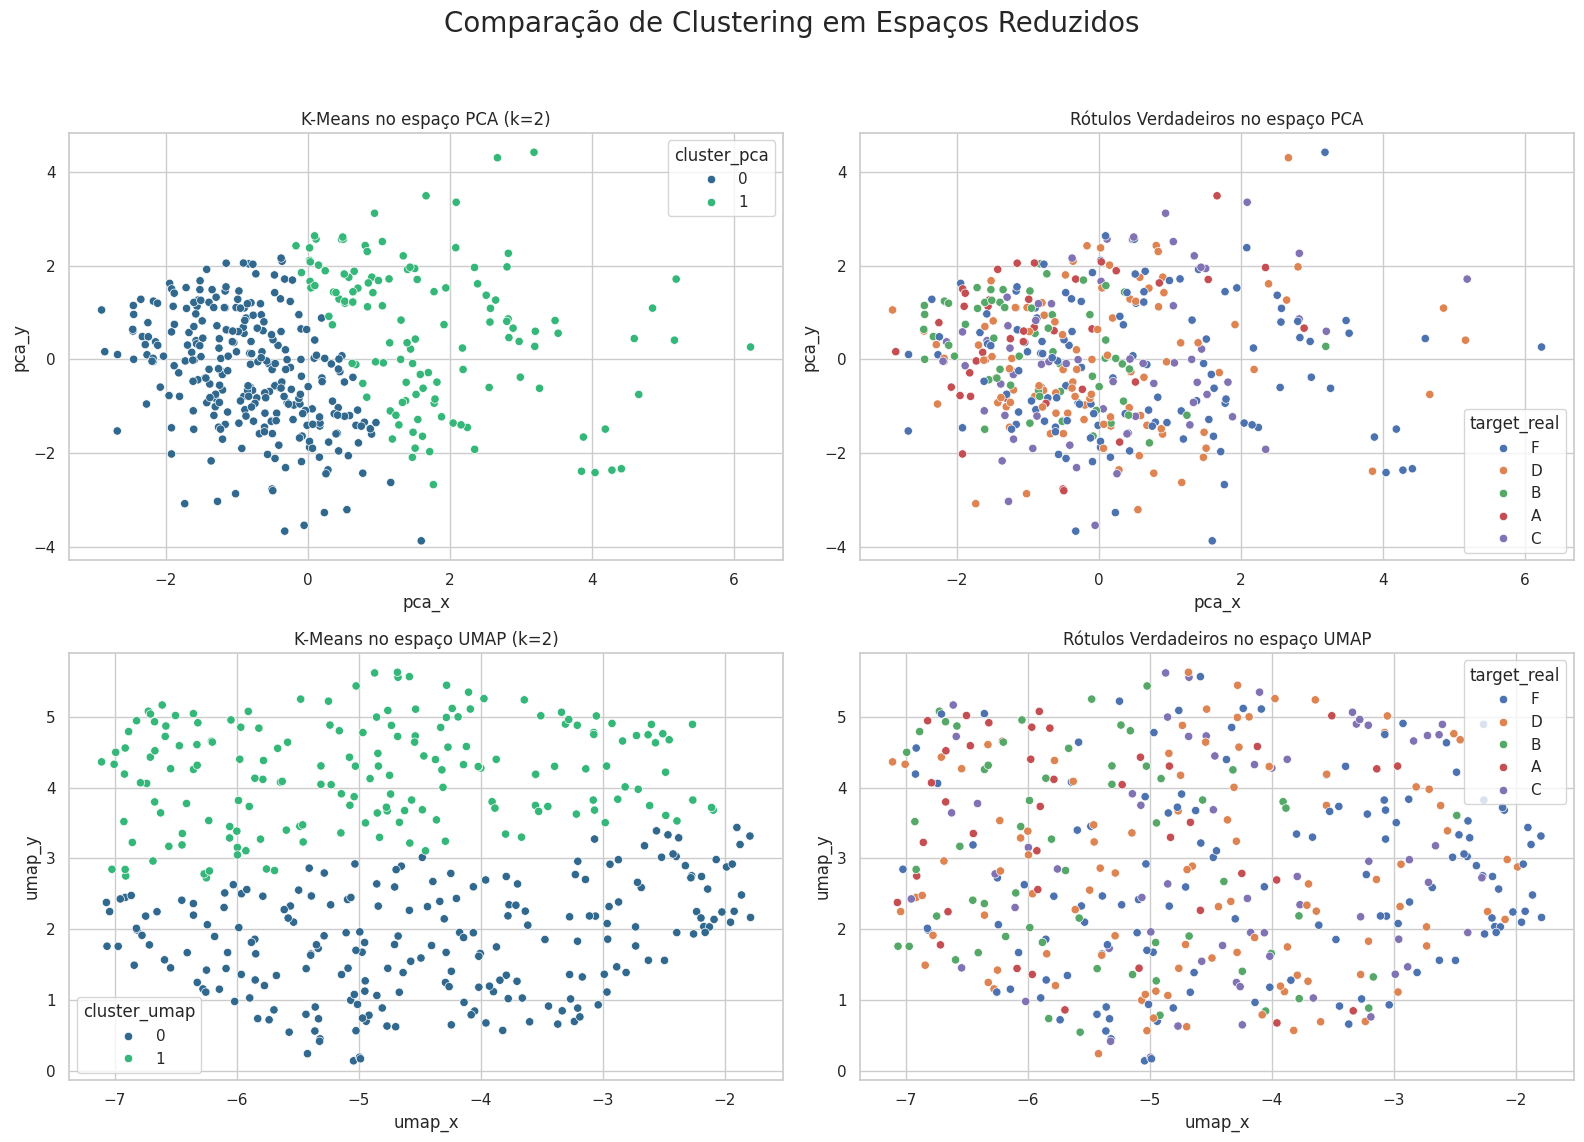

In [ ]:
# Redução de Dimensionalidade, Clustering e Visualização

# O objetivo é resolver o problema da Dimensionalidade.
# 1. Reduzimos os dados de muitas dimensões para apenas 2 usando PCA e UMAP.
# 2. Rodamos o K-Means novamente neste espaço 2D.
# 3. Visualizamos os resultados para ver se clusters mais claros emergem.

warnings.filterwarnings("ignore", category=FutureWarning)


# --- 1. Redução de Dimensionalidade ---
# PCA: Técnica linear que projeta os dados em eixos de maior variância.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_processed)
# A variância explicada mede quanto da informação original os 2 eixos do PCA capturaram.
variancia_explicada = pca.explained_variance_ratio_.sum()

# UMAP: Técnica não-linear para preservar a estrutura local dos dados.
# n_jobs=1 é usado para garantir a reprodutibilidade junto com o random_state.
umap_reducer = UMAP(n_components=2, random_state=42, n_jobs=1)
X_umap = umap_reducer.fit_transform(X_cluster_processed)

# --- 2. Preparação do DataFrame e Clustering em 2D ---
# Cria um DataFrame para armazenar as novas coordenadas 2D e os rótulos verdadeiros.
df_reduzido = pd.DataFrame({
    'pca_x': X_pca[:, 0], 'pca_y': X_pca[:, 1],
    'umap_x': X_umap[:, 0], 'umap_y': X_umap[:, 1],
    'target_real': y_true # y_true foi definido na Célula 22
})

# Roda o K-Means (k=2) nos dados reduzidos pelo PCA e calcula o novo Silhouette Score.
kmeans_pca = KMeans(n_clusters=2, random_state=42, n_init='auto').fit(df_reduzido[['pca_x', 'pca_y']])
silhouette_pca = silhouette_score(df_reduzido[['pca_x', 'pca_y']], kmeans_pca.labels_)

# Roda o K-Means (k=2) nos dados reduzidos pelo UMAP e calcula o novo Silhouette Score.
kmeans_umap = KMeans(n_clusters=2, random_state=42, n_init='auto').fit(df_reduzido[['umap_x', 'umap_y']])
silhouette_umap = silhouette_score(df_reduzido[['umap_x', 'umap_y']], kmeans_umap.labels_)

# Adiciona os novos labels de cluster ao DataFrame para a plotagem.
df_reduzido['cluster_pca'] = kmeans_pca.labels_
df_reduzido['cluster_umap'] = kmeans_umap.labels_


# --- 3. Reporte de Qualidade e Visualização ---
print("\n--- Qualidade da Representação e dos Clusters ---")
print(f"PCA: A variância explicada pelos 2 componentes é de {variancia_explicada:.2%}")
print(f"Silhouette Score dos clusters no espaço PCA: {silhouette_pca:.4f}")
print(f"Silhouette Score dos clusters no espaço UMAP: {silhouette_umap:.4f}")

# Cria uma grade de gráficos 2x2 para comparar todas as visualizações.
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparação de Clustering em Espaços Reduzidos', fontsize=20)

# Compara os clusters encontrados pelo algoritmo (esquerda) com os rótulos reais (direita).
sns.scatterplot(data=df_reduzido, x='pca_x', y='pca_y', hue='cluster_pca', palette='viridis', ax=axes[0, 0], legend='full').set_title('K-Means no espaço PCA (k=2)')
sns.scatterplot(data=df_reduzido, x='pca_x', y='pca_y', hue='target_real', palette='deep', ax=axes[0, 1], legend='full').set_title('Rótulos Verdadeiros no espaço PCA')
sns.scatterplot(data=df_reduzido, x='umap_x', y='umap_y', hue='cluster_umap', palette='viridis', ax=axes[1, 0], legend='full').set_title('K-Means no espaço UMAP (k=2)')
sns.scatterplot(data=df_reduzido, x='umap_x', y='umap_y', hue='target_real', palette='deep', ax=axes[1, 1], legend='full').set_title('Rótulos Verdadeiros no espaço UMAP')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### **Análise dos Clusters em 2D Após Redução de Dimensionalidade**

Para visualizar os agrupamentos, os dados foram projetados em um espaço 2D utilizando as técnicas de PCA e UMAP. O algoritmo K-Means (com k=2) foi escolhido e aplicado a essas novas representações, porque, após alguns testes, foi o que gerou gráficos com melhor visualização.

---

#### **Análise da Representação com PCA**

* **Qualidade da Representação:** A projeção 2D do PCA capturou **25.62%** da variância total dos dados originais. Este é um valor relativamente baixo, indicando que a estrutura dos dados é complexa e não pode ser facilmente resumida por dois eixos lineares.
* **Qualidade do Clustering:** A aplicação do K-Means neste espaço PCA resultou em um Coeficiente de Silhueta de **0.3785**. Este valor é muito superior ao valor obtido nos dados originais (~0.08).

---

#### **Análise da Representação com UMAP**

* **Qualidade da Representação:** A qualidade do UMAP é avaliada de forma qualitativa pela sua capacidade de separar os dados. Ela não fornece uma variância como o PCA para fazer essa análise.
* **Qualidade do Clustering:** Neste espaço, o K-Means alcançou um Coeficiente de Silhueta de **0.3518**, o que também representa uma melhora em relação aos dados originais.

### 3.4) Análise da melhor técnica de dimensionalidade

In [ ]:
# Análise e Perfil dos Clusters Encontrados

# O objetivo é interpretar os clusters que foram encontrados. Analisamos as características médias dos membros de cada cluster para criar um perfil para cada grupo.

# 1. Adiciona os labels do cluster (encontrados com UMAP + K-Means) ao DataFrame original.
#    Isso nos permite analisar as características originais de cada grupo.
df_clustering['cluster_encontrado'] = df_reduzido['cluster_umap']


# --- 2. Análise de Variáveis Numéricas ---
# Agrupa os dados pelo cluster encontrado e calcula a média de cada variável numérica.
# A transposição (.T) é usada para melhorar a legibilidade da tabela final.
analise_numerica = df_clustering.groupby('cluster_encontrado')[colunas_numericas].mean().T

print("--- Análise de Variáveis Numéricas (Médias por Cluster) ---")
display(analise_numerica)


# --- 3. Análise de Variáveis Categóricas ---
print("\n--- Análise de Variáveis Categóricas (Distribuição por Cluster) ---")
# Itera sobre cada coluna categórica para analisar sua distribuição dentro de cada cluster.
for col in colunas_categoricas:
    # Agrupa por cluster e calcula a distribuição percentual de cada categoria.
    # O .unstack().fillna(0) formata a saída para uma tabela de comparação fácil de ler.
    print(f"\n----- Análise da Categoria: {col} -----")
    display(df_clustering.groupby('cluster_encontrado')[col].value_counts(normalize=True).unstack().fillna(0))

--- Análise de Variáveis Numéricas (Médias por Cluster) ---


cluster_encontrado,0,1
age,16.839450,16.519774
Medu,2.064220,3.593220
Fedu,1.944954,3.231638
traveltime,1.555046,1.316384
studytime,2.119266,1.932203
failures,0.472477,0.163842
famrel,3.986239,3.892655
freetime,3.188073,3.293785
goout,2.995413,3.248588
Dalc,1.256881,1.757062



--- Análise de Variáveis Categóricas (Distribuição por Cluster) ---

----- Análise da Categoria: school -----


school,GP,MS
cluster_encontrado,,
0,0.853211,0.146789
1,0.920904,0.079096



----- Análise da Categoria: sex -----


...

higher,no,yes
cluster_encontrado,,
0,0.073394,0.926606
1,0.022599,0.977401



----- Análise da Categoria: internet -----


internet,no,yes
cluster_encontrado,,
0,0.238532,0.761468
1,0.079096,0.920904



----- Análise da Categoria: romantic -----


romantic,no,yes
cluster_encontrado,,
0,0.669725,0.330275
1,0.661017,0.338983


#### **Análise de Perfil dos Clusters**

A análise foi realizada sobre os clusters encontrados pela abordagem UMAP + K-Means. Ao avaliar as características originais dos membros de cada grupo, foi possível traçar um perfil distinto para cada um, revelando uma divisão de histórico acadêmico.

---

#### **Perfil do Cluster 1:**

Este grupo é caracterizado por um ambiente familiar com maior escolaridade.

* **Educação dos Pais:** As médias de educação da mãe (`Medu`: 3.59) e do pai (`Fedu`: 3.23) são mais altas que no outro grupo.
* **Apoio Educacional:** Recebem mais apoio familiar (`famsup`) e têm mais acesso a aulas pagas (`paid`).
* **Histórico Acadêmico:** Apresentam um número muito baixo de reprovações anteriores (`failures`).

---

#### **Perfil do Cluster 0:**

Este grupo, agrupa alunos com um perfil de maior dificuldade acadêmica e menor suporte familiar educacional.

* **Histórico Acadêmico:** A característica mais marcante é o número quase três vezes maior de reprovações anteriores (`failures`: 0.47 vs 0.16).
* **Educação dos Pais:** Os pais possuem, em média, um nível de escolaridade mais baixo.
* **Perfil Demográfico:** Este grupo possui uma proporção maior de alunas do sexo feminino (63%).

---

#### **Conclusão**

Clustering conseguiu identificar e separar de forma coerente dois grupos de alunos com perfis socioeconômicos e de histórico acadêmico distintos, revelando uma estrutura relevante e interpretável nos dados.

### 3.5) Métodos escolhidos

#### Método Escolhido e Justificativa

Dentre os métodos testados — K-Means, Gaussian Mixture Models (GMM) e HDBSCAN — o **HDBSCAN** foi o que apresentou as melhores métricas, considerando a natureza dos dados. Portanto, seria o escolhido.

#### Justificativas:

- **Métricas internas (3.2):** O HDBSCAN obteve o maior **Silhouette Score** (0.1376) e o menor **Davies-Bouldin Index** (1.70), indicando que seus clusters são mais coesos e bem separados do que os gerados pelos outros métodos. Apesar de um **Calinski-Harabasz Index** mais baixo, a qualidade geométrica dos grupos foi superior.

- **Métricas externas (3.2):** Também apresentou os maiores valores em **Adjusted Rand Index** (0.0818) e **Mutual Information** (0.3955), o que indica que seus agrupamentos, embora não perfeitos, **capturam parcialmente a estrutura presente nos rótulos reais** dos alunos (notas).

Apesar do HDBSCAN ser o escolhido, para as análises anteriores utilizei o k-means porque preferi os gráficos gerados por ele para visualização.
